In [1]:
import copy
import math
import random
import re
import time
import hashlib
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from scipy import stats
from scipy.sparse import hstack

from sklearn.base import clone
from sklearn.svm import LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer
from catboost import CatBoostClassifier
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")

# Data reading

In [2]:
from eda_benchmark import split_df, load_dataset

In [3]:
DATASET = "Tobi-Bueck/customer-support-tickets"

ds = load_dataset(DATASET)["train"]
df = ds.to_pandas()

# minimal columns check
needed = {"subject", "body", "queue", "priority", "type", "language"}
missing = sorted(list(needed - set(df.columns)))
if missing:
    raise SystemExit(f"Dataset missing columns: {missing}")
repo_root = Path('.').resolve()
dfdicts = split_df(df, repo_root)

for k in dfdicts:
    dfdicts[k]["type"] = dfdicts[k]["type"].fillna("Unknown")

# EDA

In [14]:
from eda_benchmark import basic_eda

In [15]:
basic_eda(dfdicts)


=== SIZES ===
train: 49412
val: 6176
test: 6177

=== MISSING VALUES (share) ===
train {'subject': 0.0864, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
val {'subject': 0.0818, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}
test {'subject': 0.0852, 'body': 0.0, 'queue': 0.0, 'priority': 0.0, 'type': 0.0, 'language': 0.0}

=== TEXT LENGTHS (train) ===
chars:  mean=464.8  p50=460  p90=755  p99=999
words:  mean=62.4  p50=62  p90=99  p99=143

=== TEXT LENGTHS (val) ===
chars:  mean=466.7  p50=463  p90=753  p99=1010
words:  mean=62.7  p50=62  p90=98  p99=142

=== TEXT LENGTHS (test) ===
chars:  mean=460.3  p50=454  p90=751  p99=1015
words:  mean=62.1  p50=62  p90=98  p99=147

=== LANGUAGE DISTRIBUTION ===
train {'de': 0.5424, 'en': 0.4576}
val {'de': 0.5465, 'en': 0.4535}
test {'de': 0.5391, 'en': 0.4609}

=== CLASS COVERAGE: queue ===
train: classes=52  missing_vs_train=0
val: classes=52  missing_vs_train=0
test: classes=52  missing_vs

---

Тут описываю результаты basic и advanced EDA (basic выше, а advanced ниже)

Результаты анализы EDA:

- В выборке 49 412 train, 6 176 val и 6 177 test.

- Пропуски есть почти только в subject: около 8-9% во всех сплитах. body и все таргеты заполнены.

- Тексты по длине довольно однородны: медиана примерно 450–460 символов и около 62 слов. Значит, нет проблемы, что часть объектов очень короткие, а часть экстремально длинные.

- Языки распределены ровно: примерно 54% немецких и 46% английских текстов во всех сплитах.

- Все 52 класса queue, 5 классов priority и 5 классов type присутствуют во всех сплитах. Это тоже плюс.

Одна из основных проблем EDA — сильный дисбаланс классов, особенно в queue.

- Самый частый класс Technical Support занимает примерно 23% train.

- Дальше тоже есть крупные классы вроде Product Support, Customer Service, IT Support.

- При этом хвостовые классы имеют около 187–232 наблюдений.

- То есть задача маршрутизации явно несбалансированная: модель будет склонна лучше предсказывать крупные очереди и хуже редкие.

По priority дисбаланс тоже есть, но он мягче:

- доминируют medium, high, low,

- critical и very_low заметно реже.

Расширенный EDA показывает еще несколько важных моментов:

- выбросов по длине текста мало: около 0.4–0.5%, то есть экстремально длинных/странных текстов почти нет;

- URL и email почти отсутствуют, значит модель вряд ли сможет опираться на такие явные шаблонные признаки;

- пустой body практически не встречается;

- точных дубликатов очень много: около 26–27% внутри каждого сплита;

- найден 1 объект, который попал сразу в несколько сплитов, то есть есть минимальная, но все же утечка данных между train/val/test.

In [18]:
def advance_eda(splits: dict[str, pd.DataFrame], save_dir: str | None = None, outlier_method: str = "iqr", detect_near_duplicates: bool = False, near_dup_threshold: float = 0.9) -> None:
    if save_dir:
        Path(save_dir).mkdir(parents=True, exist_ok=True)
    
    def _save_or_show(fig_name: str):
        if save_dir:
            plt.savefig(Path(save_dir) / f"{fig_name}.png", dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()
    
    def _detect_outliers(series: pd.Series, method: str = "iqr") -> pd.Series:
        if method == "iqr":
            q1, q3 = series.quantile(0.25), series.quantile(0.75)
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            return (series < lower) | (series > upper)
        elif method == "zscore":
            z = np.abs(stats.zscore(series.dropna()))
            outlier_mask = pd.Series(False, index=series.index)
            outlier_mask[z > 3] = True
            return outlier_mask
        return pd.Series(False, index=series.index)
    
    def _text_features(df: pd.DataFrame, text_cols: list[str] = None) -> pd.DataFrame:
        if text_cols is None:
            text_cols = ["subject", "body"]
        feats = pd.DataFrame(index=df.index)
        for col in text_cols:
            if col not in df.columns:
                continue
            txt = df[col].fillna("").astype(str)
            feats[f"{col}_len_chars"] = txt.str.len()
            feats[f"{col}_len_words"] = txt.str.split().str.len()
            feats[f"{col}_len_sents"] = txt.str.count(r"[.!?]+")
            feats[f"{col}_uppercase_ratio"] = txt.str.count(r"[A-Z]") / feats[f"{col}_len_chars"].replace(0, 1)
            feats[f"{col}_digit_ratio"] = txt.str.count(r"\d") / feats[f"{col}_len_chars"].replace(0, 1)
            feats[f"{col}_special_ratio"] = txt.str.count(r"[^a-zA-Z0-9\s]") / feats[f"{col}_len_chars"].replace(0, 1)
            feats[f"{col}_url_count"] = txt.str.count(r"https?://\S+|www\.\S+")
            feats[f"{col}_email_count"] = txt.str.count(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[a-zA-Z]{2,}\b")
            feats[f"{col}_empty"] = txt.str.strip().eq("")
        if "subject" in df.columns and "body" in df.columns:
            sub = df["subject"].fillna("").astype(str)
            bod = df["body"].fillna("").astype(str)
            feats["subject_in_body"] = [s.lower() in b.lower() for s, b in zip(sub, bod)]
        return feats
    
    def _normalize_text(text: str) -> str:
        text = text.lower().strip()
        text = re.sub(r"\s+", " ", text)
        text = re.sub(r"[^\w\s]", "", text)
        return text
    
    def _find_exact_duplicates(df: pd.DataFrame, text_cols: list[str] = None) -> pd.Series:
        if text_cols is None:
            text_cols = ["subject", "body"]
        combined = df[text_cols].fillna("").astype(str).agg(" ||| ".join, axis=1)
        normalized = combined.apply(_normalize_text)
        hashes = normalized.apply(lambda x: hashlib.md5(x.encode()).hexdigest())
        return hashes.duplicated(keep=False)
    
    def _find_cross_split_duplicates(splits: dict[str, pd.DataFrame], text_cols: list[str] = None) -> dict:
        if text_cols is None:
            text_cols = ["subject", "body"]
        results = {}
        hash_to_split = {}
        for split_name, df in splits.items():
            combined = df[text_cols].fillna("").astype(str).agg(" ||| ".join, axis=1)
            normalized = combined.apply(_normalize_text)
            for idx, txt in normalized.items():
                h = hashlib.md5(txt.encode()).hexdigest()
                if h not in hash_to_split:
                    hash_to_split[h] = []
                hash_to_split[h].append((split_name, idx))
        for h, occurrences in hash_to_split.items():
            if len(occurrences) > 1:
                split_names = [o[0] for o in occurrences]
                if len(set(split_names)) > 1:
                    results[h] = occurrences
        return results
    
    def _find_near_duplicates(df: pd.DataFrame, threshold: float = 0.9, text_cols: list[str] = None, sample_size: int = 5000) -> pd.Series:
        if text_cols is None:
            text_cols = ["subject", "body"]
        combined = df[text_cols].fillna("").astype(str).agg(" [SEP] ".join, axis=1)
        normalized = combined.apply(_normalize_text)
        if len(normalized) > sample_size:
            sampled_idx = np.random.choice(normalized.index, size=sample_size, replace=False)
            texts_sample = normalized.loc[sampled_idx]
        else:
            texts_sample = normalized
            sampled_idx = normalized.index
        vectorizer = TfidfVectorizer(ngram_range=(2, 4), max_features=5000, min_df=2)
        try:
            tfidf = vectorizer.fit_transform(texts_sample)
        except ValueError:
            return pd.Series(False, index=df.index)
        sim_matrix = cosine_similarity(tfidf)
        np.fill_diagonal(sim_matrix, 0)
        duplicate_mask = pd.Series(False, index=df.index)
        for i, idx in enumerate(texts_sample.index):
            if (sim_matrix[i] >= threshold).any():
                duplicate_mask[idx] = True
        return duplicate_mask
    
    def _get_vocab(df: pd.DataFrame, cols: list[str] = None) -> set:
        if cols is None:
            cols = ["subject", "body"]
        txt = " ".join(df[c].fillna("").astype(str).str.cat(sep=" ") for c in cols if c in df.columns)
        return set(re.findall(r"\b[a-z]{2,}\b", txt))
    
    duplicate_report = {}
    
    for k, d in splits.items():
        feats = _text_features(d)
        char_len = feats.filter(like="_len_chars").sum(axis=1)
        word_len = feats.filter(like="_len_words").sum(axis=1)
        
        outlier_mask_char = _detect_outliers(char_len, outlier_method)
        outlier_mask_word = _detect_outliers(word_len, outlier_method)
        
        exact_dup_mask = _find_exact_duplicates(d)
        dup_count = exact_dup_mask.sum()
        duplicate_report[k] = {"exact_duplicates": int(dup_count), "exact_dup_pct": 100 * dup_count / len(d) if len(d) > 0 else 0}
        
        if detect_near_duplicates and len(d) > 100:
            near_dup_mask = _find_near_duplicates(d, threshold=near_dup_threshold)
            duplicate_report[k]["near_duplicates"] = int(near_dup_mask.sum())
            duplicate_report[k]["near_dup_pct"] = 100 * near_dup_mask.sum() / len(d)
        
        fig, axes = plt.subplots(3, 3, figsize=(18, 14))
        axes = axes.ravel()
        
        sns.histplot(char_len, bins=60, kde=True, ax=axes[0], color="#2E86AB", line_kws={"linewidth": 2})
        axes[0].axvline(char_len.median(), color="#A23B72", linestyle="--", label=f"median={char_len.median():.0f}")
        axes[0].axvline(char_len.quantile(0.9), color="#F18F01", linestyle="--", label=f"p90={char_len.quantile(0.9):.0f}")
        axes[0].axvspan(char_len.quantile(0.99), char_len.max(), alpha=0.1, color="red", label="top 1%")
        axes[0].set_title(f"{k} — Character Length (outliers: {outlier_mask_char.sum()})")
        axes[0].set_xlabel("Characters"); axes[0].legend(fontsize=8)
        
        sns.histplot(word_len, bins=60, kde=True, ax=axes[1], color="#C73E1D")
        axes[1].axvline(word_len.median(), color="#A23B72", linestyle="--")
        axes[1].set_title(f"{k} — Word Count (outliers: {outlier_mask_word.sum()})")
        axes[1].set_xlabel("Words")
        
        sns.boxplot(x=char_len, ax=axes[2], color="#E9D8A6", showfliers=True)
        axes[2].set_title(f"{k} — Char Length Boxplot (with outliers)")
        
        special_ratio = feats.filter(like="_special_ratio").mean(axis=1)
        axes[3].scatter(char_len[~outlier_mask_char], special_ratio[~outlier_mask_char], s=10, alpha=0.3, label="normal", color="#06A77D")
        axes[3].scatter(char_len[outlier_mask_char], special_ratio[outlier_mask_char], s=30, alpha=0.8, label="outlier", color="#D62828", edgecolors="black")
        axes[3].set_xlabel("Character Length"); axes[3].set_ylabel("Special Char Ratio")
        axes[3].set_title(f"{k} — Outliers: Length vs Special Chars"); axes[3].legend(); axes[3].grid(alpha=0.3)
        
        empty_cols = [c for c in feats.columns if c.endswith("_empty")]
        if empty_cols:
            empty_matrix = feats[empty_cols].astype(int).corr()
            sns.heatmap(empty_matrix, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=axes[4], square=True)
            axes[4].set_title(f"{k} — Empty Field Correlation")
        
        url_counts = feats.filter(like="_url_count").sum(axis=1)
        email_counts = feats.filter(like="_email_count").sum(axis=1)
        axes[5].hist([url_counts[url_counts>0], email_counts[email_counts>0]], label=["URLs", "Emails"], bins=20, alpha=0.7)
        axes[5].set_title(f"{k} — URL/Email Counts (non-zero)")
        axes[5].set_xlabel("Count"); axes[5].legend(); axes[5].grid(alpha=0.3)
        
        uppercase_ratio = feats.filter(like="_uppercase_ratio").mean(axis=1)
        sns.kdeplot(uppercase_ratio, ax=axes[6], fill=True, color="#9D4EDD")
        axes[6].axvline(uppercase_ratio.mean(), color="red", linestyle="--", label=f"mean={uppercase_ratio.mean():.3f}")
        axes[6].set_title(f"{k} — Uppercase Ratio Distribution"); axes[6].set_xlabel("Ratio"); axes[6].legend()
        
        if "subject_in_body" in feats.columns:
            sib = feats["subject_in_body"].value_counts(normalize=True)
            axes[7].pie(sib.values, labels=[f"Subject in body: {sib.get(True, 0):.1%}", f"Not in body: {sib.get(False, 0):.1%}"], autopct="%.1f%%", colors=["#06A77D", "#D62828"])
            axes[7].set_title(f"{k} — Subject Mentioned in Body")
        
        stats_df = pd.DataFrame({
            "metric": ["mean_chars", "median_chars", "std_chars", "outliers_%", "mean_words", "median_words", "empty_subject_%", "empty_body_%", "mean_urls", "mean_emails", "exact_dup_count", "exact_dup_%"],
            "value": [char_len.mean(), char_len.median(), char_len.std(), 100*outlier_mask_char.mean(), word_len.mean(), word_len.median(), 100*feats["subject_empty"].mean(), 100*feats["body_empty"].mean(), url_counts.mean(), email_counts.mean(), duplicate_report[k]["exact_duplicates"], duplicate_report[k]["exact_dup_pct"]]
        })
        axes[8].axis("off")
        table = axes[8].table(cellText=stats_df.values, colLabels=stats_df.columns, loc="center", cellLoc="left")
        table.auto_set_font_size(False); table.set_fontsize(7); table.scale(1.2, 1.6)
        axes[8].set_title(f"{k} — Key Statistics", pad=15)
        
        plt.suptitle(f"Advanced Text Analysis — {k.upper()}", fontsize=16, fontweight="bold", y=0.995)
        plt.tight_layout()
        _save_or_show(f"advanced_text_analysis_{k}")
    
    cross_split_dups = _find_cross_split_duplicates(splits)
    print(f"\n CROSS-SPLIT DUPLICATES (DATA LEAKAGE CHECK)")
    print(f"   Found {len(cross_split_dups):,} samples appearing in multiple splits")
    
    if cross_split_dups:
        leakage_matrix = pd.DataFrame(0, index=splits.keys(), columns=splits.keys())
        for h, occurrences in cross_split_dups.items():
            split_set = set(o[0] for o in occurrences)
            for s1 in split_set:
                for s2 in split_set:
                    if s1 != s2:
                        leakage_matrix.loc[s1, s2] += 1
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        sns.heatmap(leakage_matrix.astype(int), annot=True, fmt="d", cmap="Reds", ax=ax, square=True)
        ax.set_title("Cross-Split Duplicate Count (Data Leakage!)")
        ax.set_xlabel("Split"); ax.set_ylabel("Split")
        plt.tight_layout()
        _save_or_show("cross_split_duplicates")
    
    for target in ["queue", "priority", "type"]:
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        
        for ax, (k, d) in zip(axes.flat[:3], splits.items()):
            vc = d[target].astype(str).value_counts(normalize=True)
            gini = (2 * vc.cumsum().sum() / len(vc)) - (len(vc) + 1) / len(vc)
            entropy = stats.entropy(vc, base=2)
            sns.barplot(x=vc.values[:20], y=vc.index[:20], ax=ax, palette="mako")
            ax.set_title(f"{k}\nGini={gini:.3f}, Entropy={entropy:.2f} bits")
            ax.set_xlabel("Share"); ax.set_ylabel("")
        
        all_classes = set()
        for d in splits.values():
            all_classes.update(d[target].astype(str).unique())
        overlap_matrix = pd.DataFrame(index=splits.keys(), columns=splits.keys())
        for k1 in splits:
            for k2 in splits:
                set1, set2 = set(splits[k1][target].astype(str)), set(splits[k2][target].astype(str))
                overlap_matrix.loc[k1, k2] = len(set1 & set2) / len(set1 | set2) if set1 | set2 else 1.0
        sns.heatmap(overlap_matrix.astype(float), annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1,1], square=True)
        axes[1,1].set_title(f"{target} — Jaccard Overlap Between Splits")
        
        plt.suptitle(f"Class Analysis: {target.upper()}", fontsize=16, fontweight="bold", y=1.02)
        plt.tight_layout()
        _save_or_show(f"class_analysis_{target}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    train = splits["train"]
    
    if "queue" in train.columns and "priority" in train.columns:
        cooc_qp = pd.crosstab(train["queue"].astype(str), train["priority"].astype(str))
        sns.heatmap(cooc_qp.div(cooc_qp.sum(axis=1), axis=0), annot=False, cmap="Blues", ax=axes[0], cbar_kws={"label": "P(priority|queue)"})
        axes[0].set_title("P(Priority | Queue) — Train")
        axes[0].tick_params(axis="x", rotation=45)
    
    if "queue" in train.columns and "type" in train.columns:
        cooc_qt = pd.crosstab(train["queue"].astype(str), train["type"].astype(str))
        sns.heatmap(cooc_qt.div(cooc_qt.sum(axis=1), axis=0), annot=False, cmap="Greens", ax=axes[1], cbar_kws={"label": "P(type|queue)"})
        axes[1].set_title("P(Type | Queue) — Train")
        axes[1].tick_params(axis="x", rotation=45)
    
    plt.suptitle("Multitask Label Co-occurrence Patterns", fontsize=16, fontweight="bold", y=1.05)
    plt.tight_layout()
    _save_or_show("label_cooccurrence")
    
    vocab_overlap = pd.DataFrame(index=["train", "val", "test"], columns=["train", "val", "test"], dtype=float)
    vocabs = {k: _get_vocab(d) for k, d in splits.items()}
    for k1 in vocabs:
        for k2 in vocabs:
            vocab_overlap.loc[k1, k2] = len(vocabs[k1] & vocabs[k2]) / len(vocabs[k1] | vocabs[k2]) if vocabs[k1] | vocabs[k2] else 1.0
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sns.heatmap(vocab_overlap.astype(float), annot=True, fmt=".2f", cmap="Purples", ax=ax, square=True)
    ax.set_title("Vocabulary Jaccard Overlap (lowercased words, len≥2)")
    plt.tight_layout()
    _save_or_show("vocabulary_overlap")
    
    print("\n" + "="*70)
    print("ADVANCED EDA SUMMARY REPORT")
    print("="*70)
    for k, d in splits.items():
        feats = _text_features(d)
        char_len = feats.filter(like="_len_chars").sum(axis=1)
        outlier_pct = 100 * _detect_outliers(char_len, outlier_method).mean()
        print(f"\n[{k.upper()}]")
        print(f"  Samples: {len(d):,}")
        print(f"  Text length — mean: {char_len.mean():.0f} chars, median: {char_len.median():.0f}, outliers: {outlier_pct:.2f}%")
        print(f"  Empty fields — subject: {feats['subject_empty'].mean()*100:.2f}%, body: {feats['body_empty'].mean()*100:.2f}%")
        print(f"  Avg URLs: {feats.filter(like='_url_count').sum(axis=1).mean():.2f}, Emails: {feats.filter(like='_email_count').sum(axis=1).mean():.2f}")
        print(f"  Exact duplicates: {duplicate_report[k]['exact_duplicates']} ({duplicate_report[k]['exact_dup_pct']:.2f}%)")
        if detect_near_duplicates and "near_duplicates" in duplicate_report[k]:
            print(f"  Near-duplicates (≥{near_dup_threshold*100:.0f}% similar): {duplicate_report[k]['near_duplicates']} ({duplicate_report[k]['near_dup_pct']:.2f}%)")
        for target in ["queue", "priority", "type"]:
            if target in d.columns:
                vc = d[target].astype(str).value_counts()
                print(f"  {target}: {len(vc)} classes, top: '{vc.index[0]}' ({vc.iloc[0]/len(d)*100:.1f}%), Gini: {(2*vc.cumsum().sum()/len(vc) - (len(vc)+1)/len(vc)):.3f}")
    
    if cross_split_dups:
        print(f"\n WARNING: {len(cross_split_dups):,} samples found in multiple splits (DATA LEAKAGE!)")
        print("   Consider removing duplicates or regenerating split indices.")

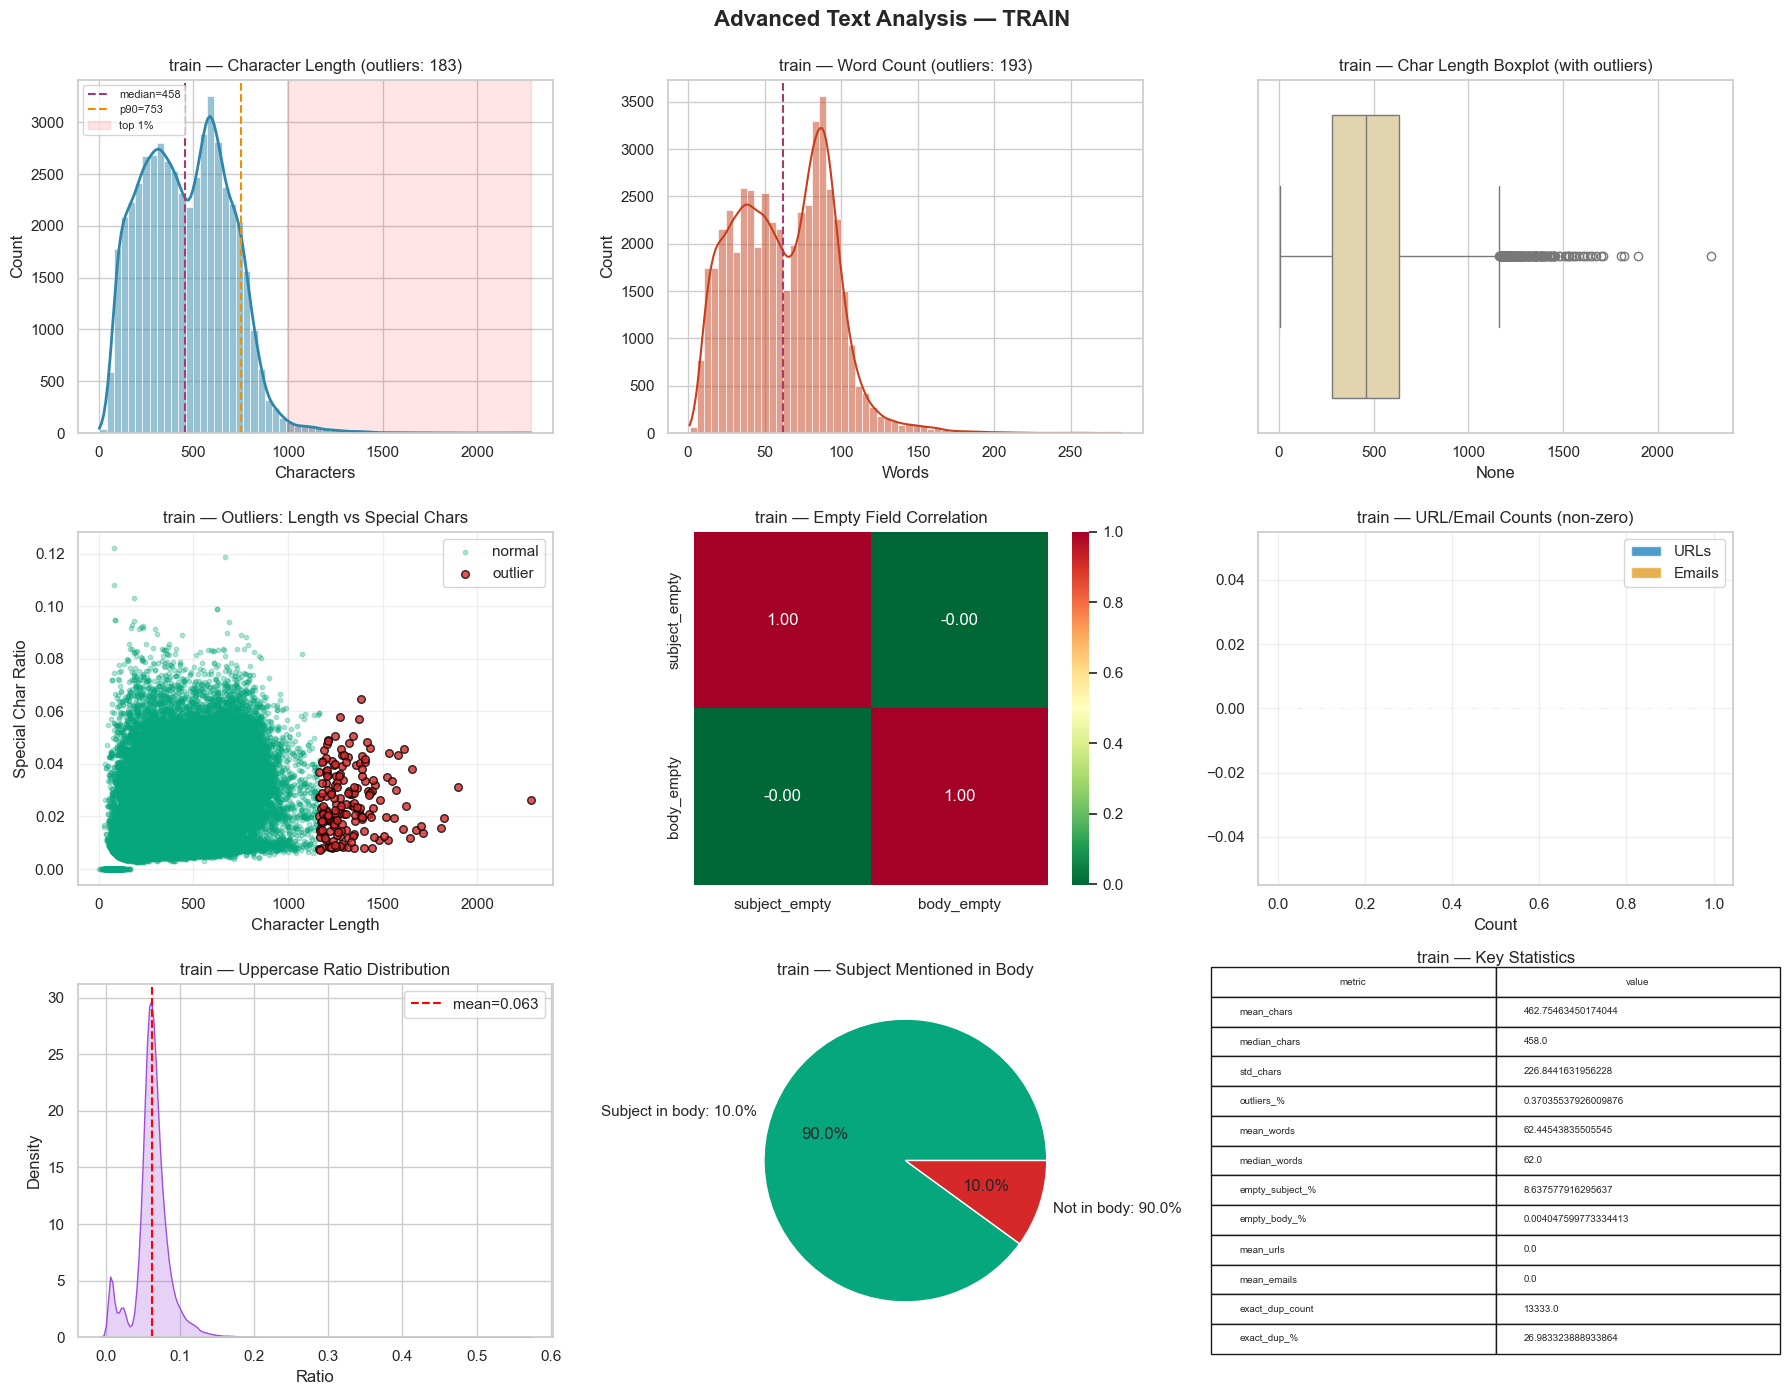

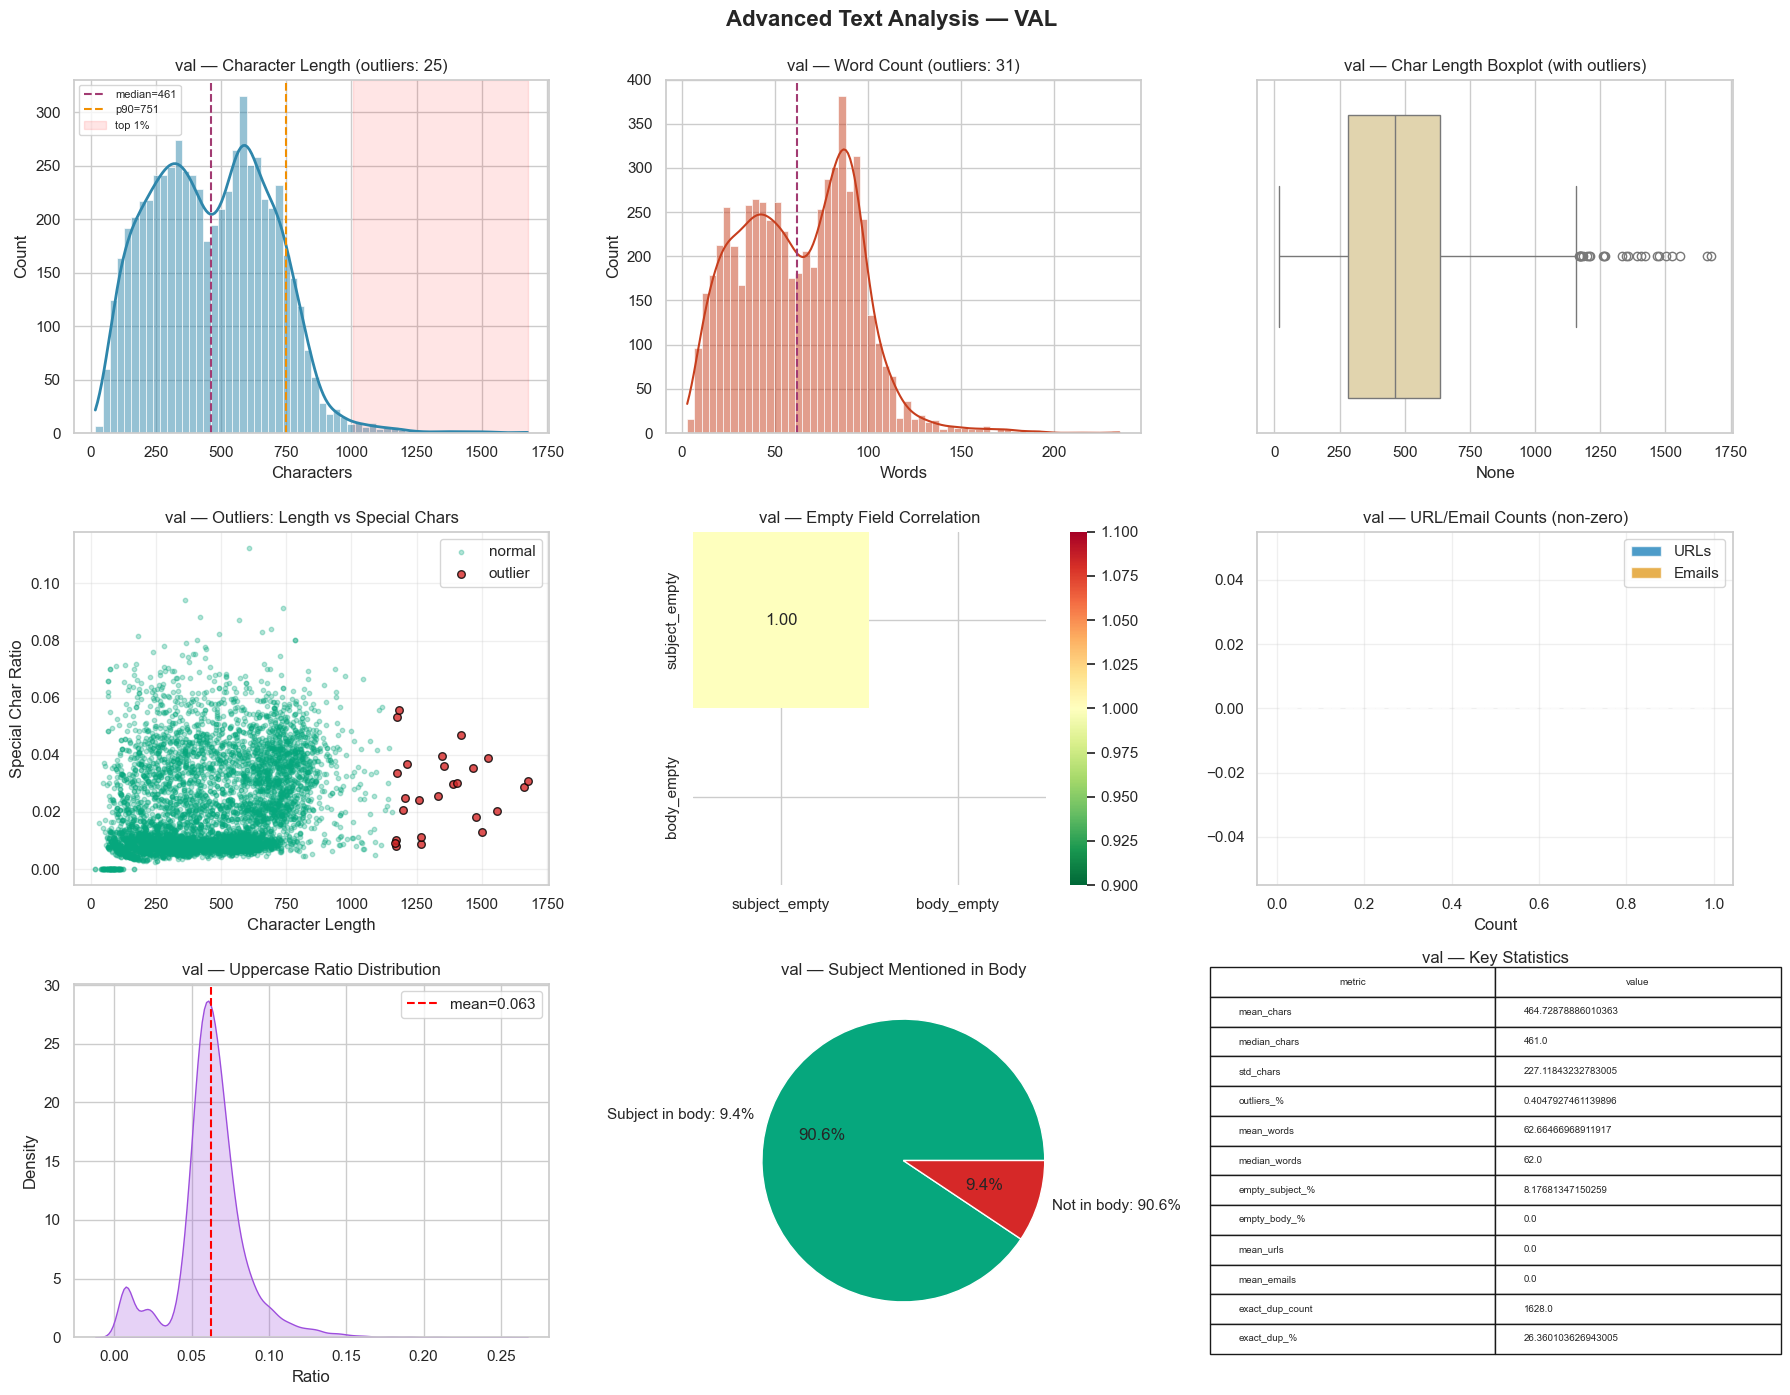

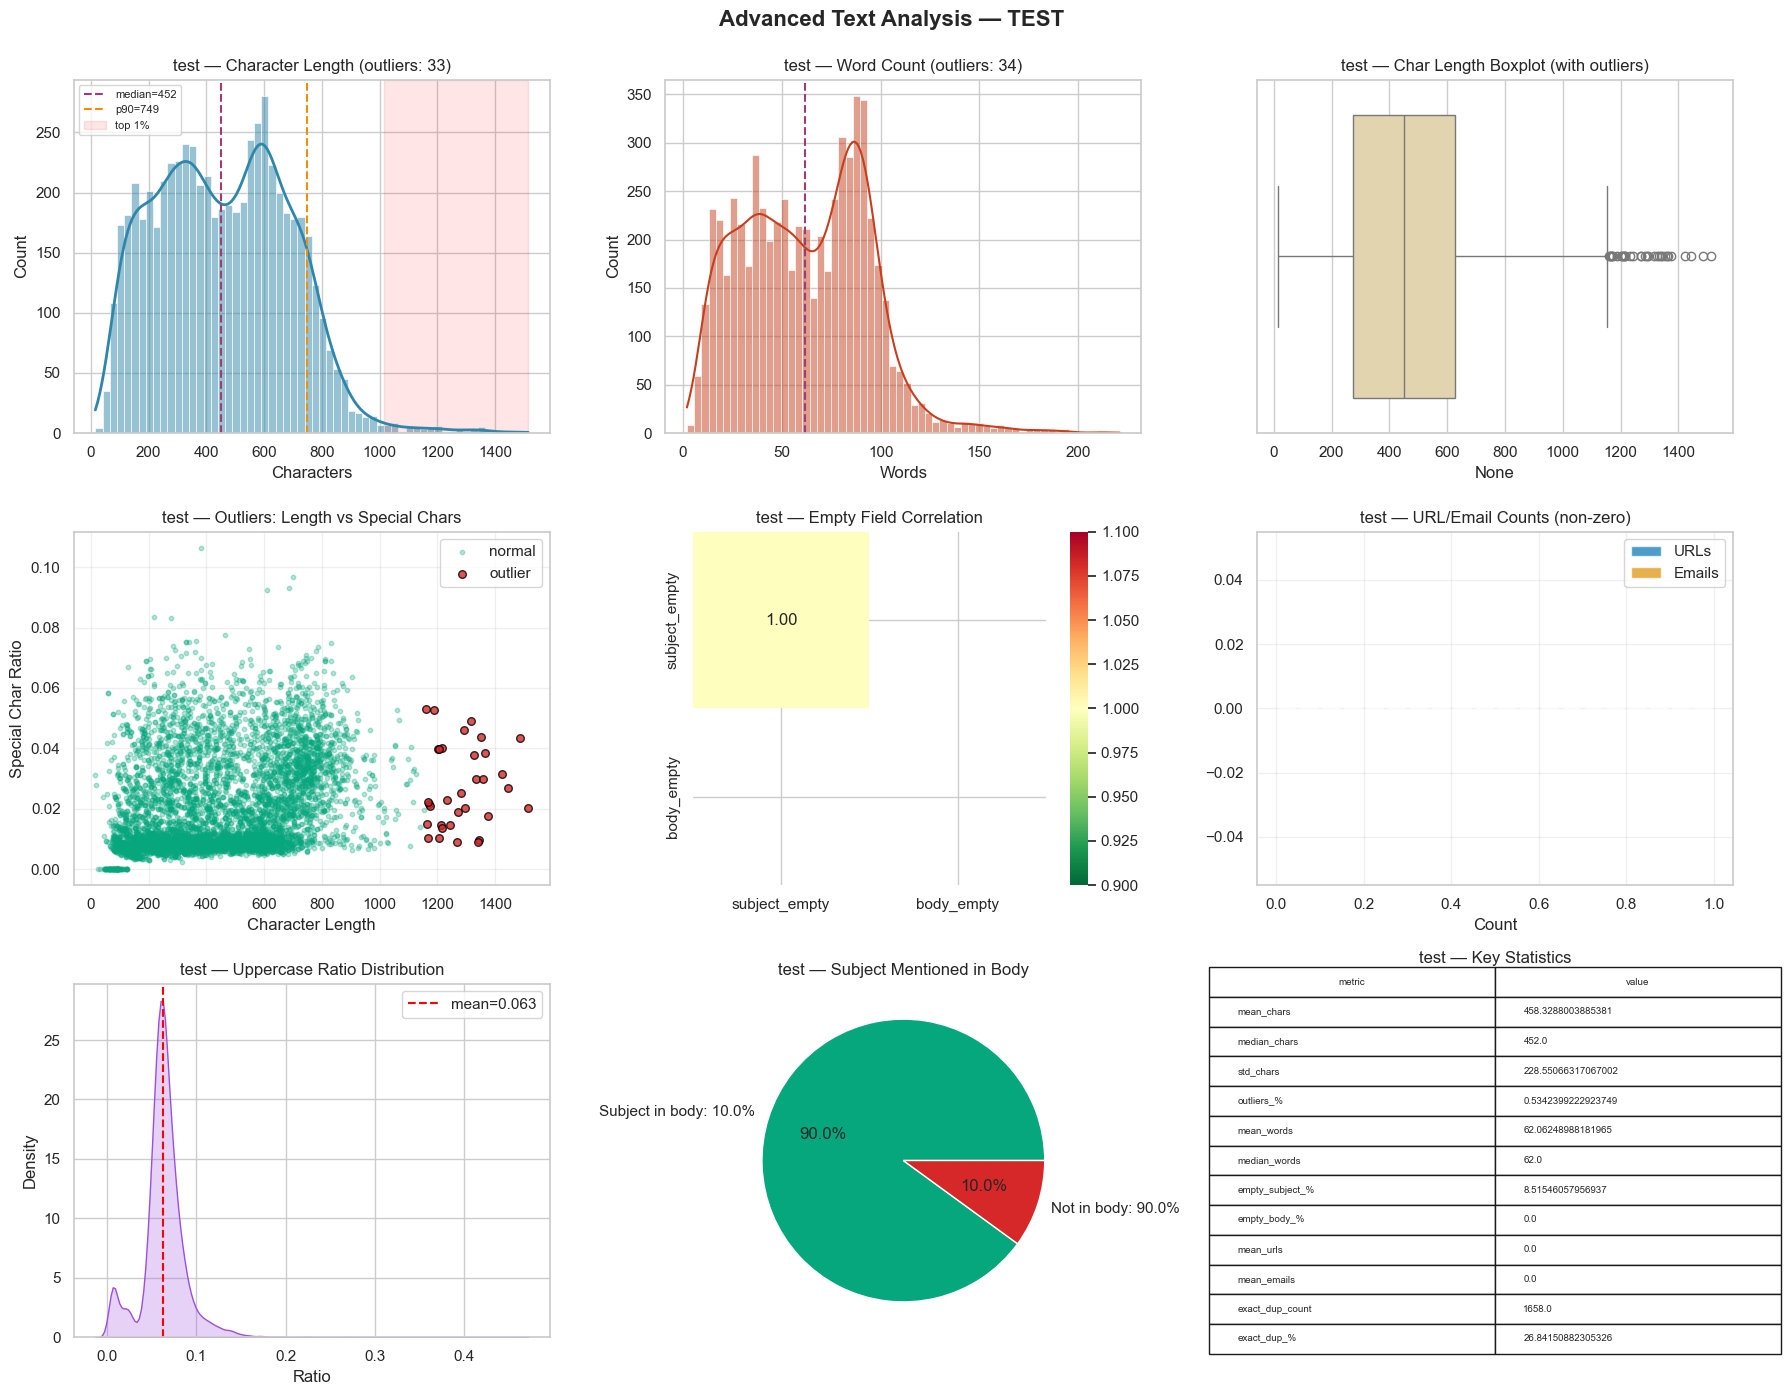


 CROSS-SPLIT DUPLICATES (DATA LEAKAGE CHECK)
   Found 1 samples appearing in multiple splits


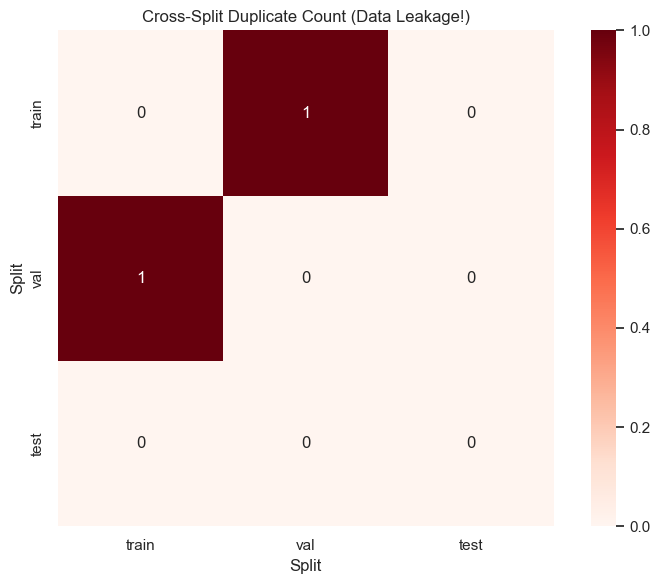

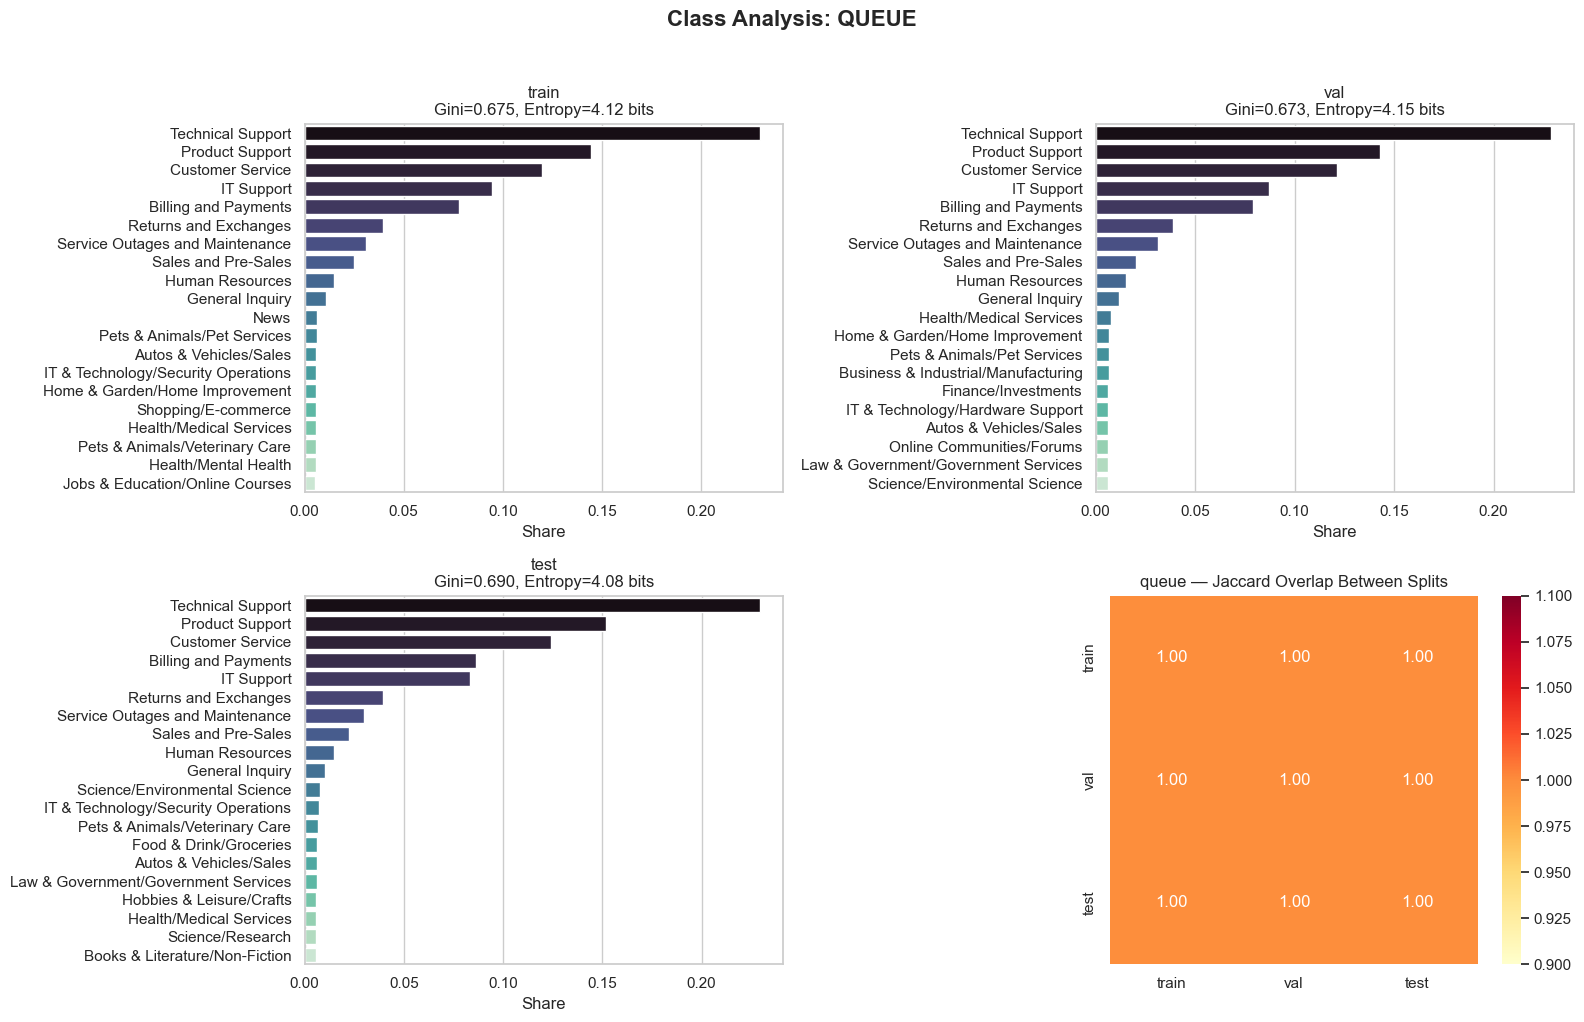

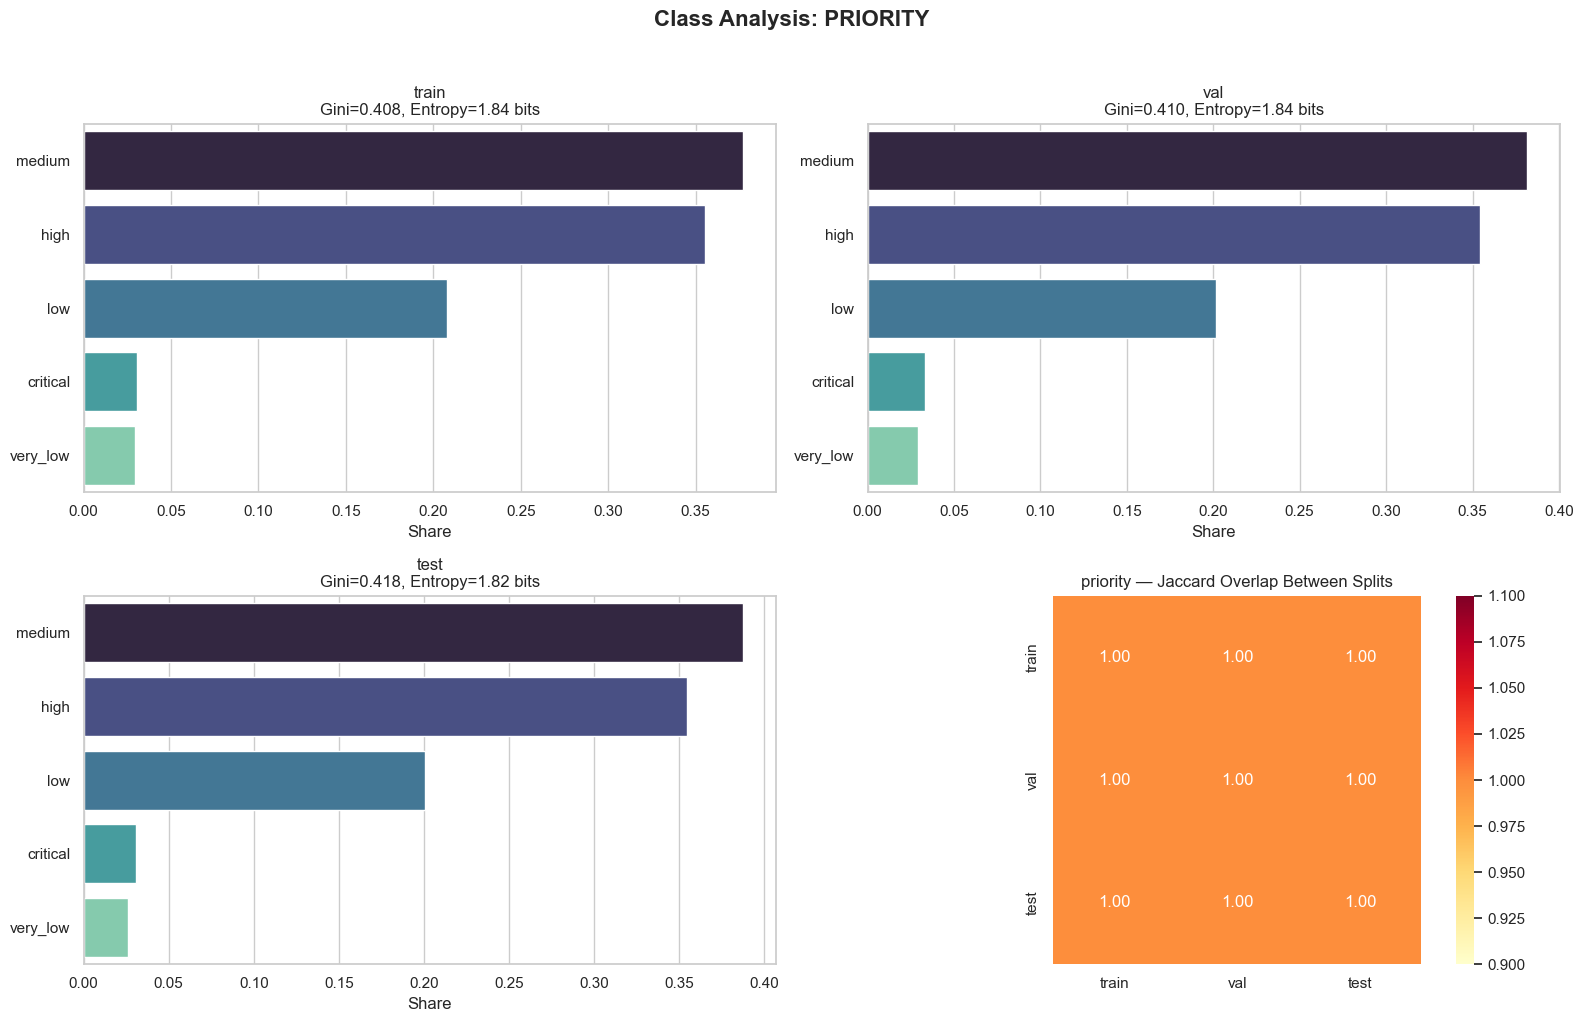

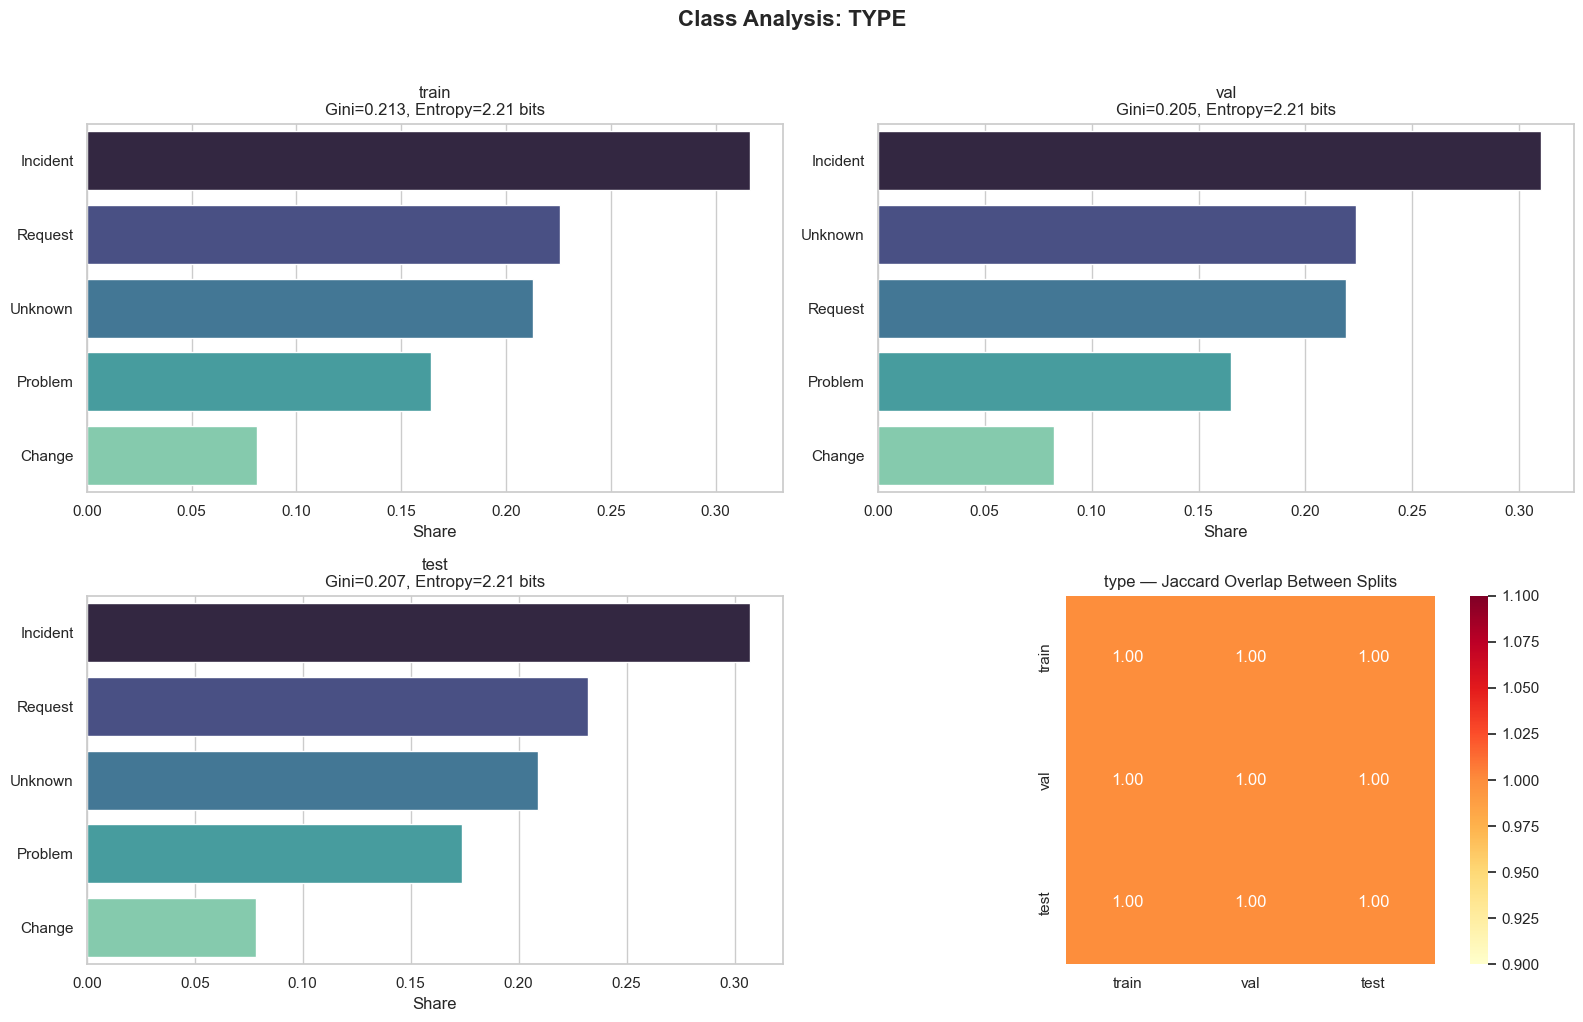

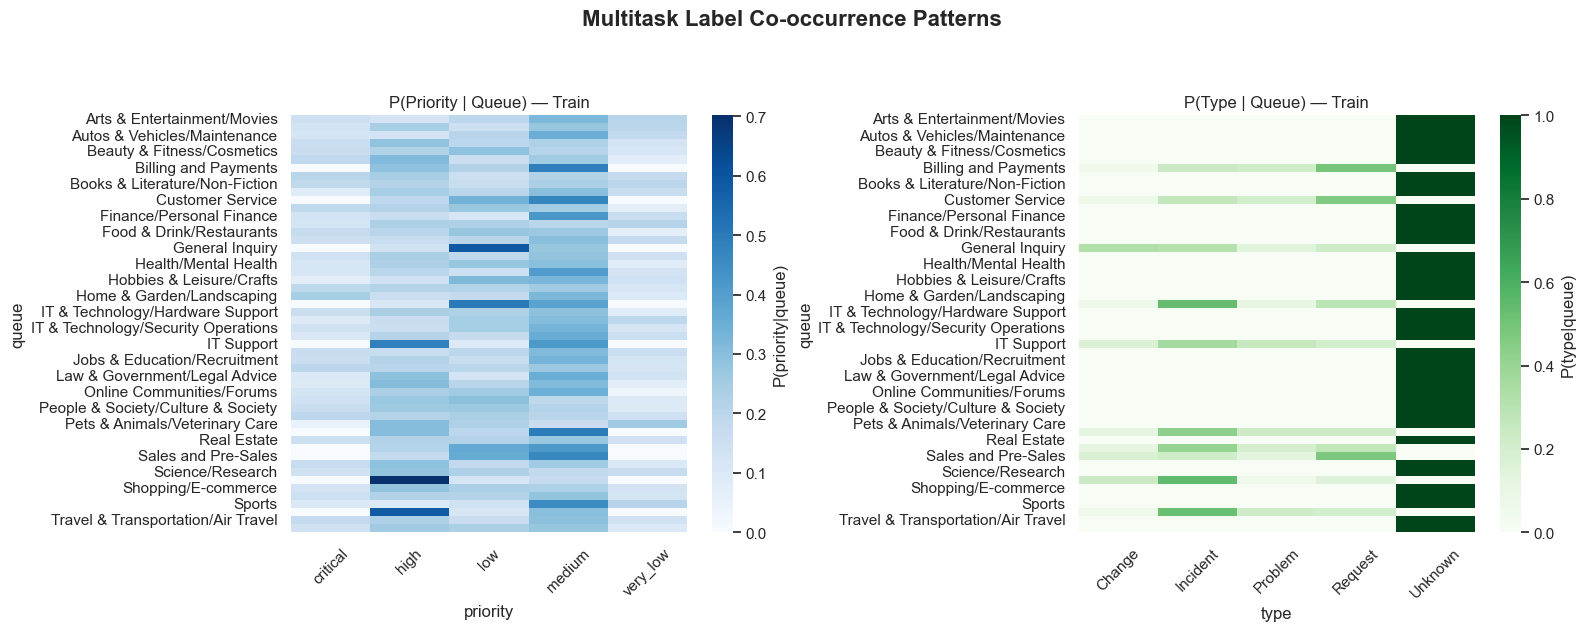

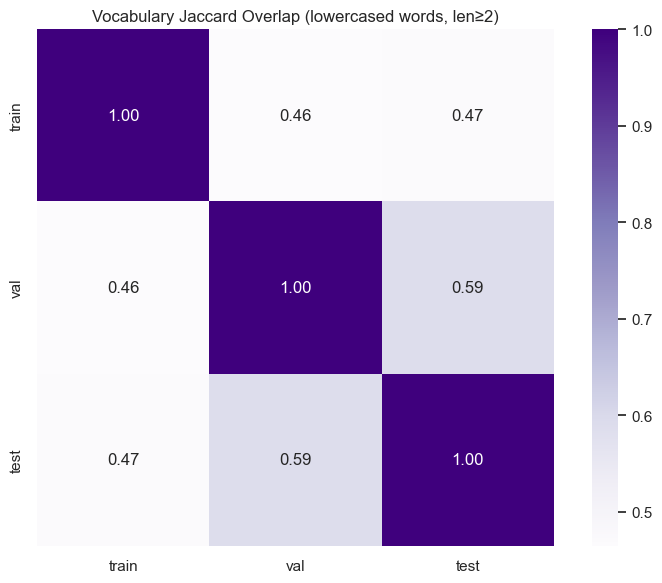


ADVANCED EDA SUMMARY REPORT

[TRAIN]
  Samples: 49,412
  Text length — mean: 463 chars, median: 458, outliers: 0.37%
  Empty fields — subject: 8.64%, body: 0.00%
  Avg URLs: 0.00, Emails: 0.00
  Exact duplicates: 13333 (26.98%)
  queue: 52 classes, top: 'Technical Support' (23.0%), Gini: 83701.635
  priority: 5 classes, top: 'medium' (37.7%), Gini: 79455.600
  type: 5 classes, top: 'Incident' (31.6%), Gini: 69820.400

[VAL]
  Samples: 6,176
  Text length — mean: 465 chars, median: 461, outliers: 0.40%
  Empty fields — subject: 8.18%, body: 0.00%
  Avg URLs: 0.00, Emails: 0.00
  Exact duplicates: 1628 (26.36%)
  queue: 52 classes, top: 'Technical Support' (22.9%), Gini: 10448.288
  priority: 5 classes, top: 'medium' (38.1%), Gini: 9944.400
  type: 5 classes, top: 'Incident' (31.0%), Gini: 8678.000

[TEST]
  Samples: 6,177
  Text length — mean: 458 chars, median: 452, outliers: 0.53%
  Empty fields — subject: 8.52%, body: 0.00%
  Avg URLs: 0.00, Emails: 0.00
  Exact duplicates: 1658 (26

In [17]:
advance_eda(dfdicts)

# Baseline modeling and experiments

In [42]:
from eda_benchmark import baseline_tfidf_linear_svm

In [43]:
baseline_tfidf_linear_svm(dfdicts)


=== BASELINE: TF-IDF + LinearSVC ===
queue: acc=0.6914  macro_f1=0.8940
priority: acc=0.7112
type: acc=0.8974

=== FINAL SCORE (baseline) ===
Score = 0.8671  (0.70*MacroF1(queue) + 0.15*Acc(priority) + 0.15*Acc(type))


---

Линейная модель на TF-IDF работает хорошо.

Далее сделал блок экспериментов, где подбор делается в три этапа:
1) Quick feature screening - сравниваю разные варианты текстовых признаков на уменьшенной подвыборке
   - только word n-gram TF-IDF
   - только char n-gram TF-IDF
   - гибрид word + char

Постарался не тратить много времени на полный перебор всех моделей, а сначала понять, какое представление текста вообще наиболее перспективно.

По результатам видно:
   - word-only признаки заметно слабее
   - char-only признаки лучше word-only
   - лучшие результаты дают hybrid-признаки

2) full train/val model sweep - после отбора лучших наборов признаков берутся top-конфигурации и уже на полном train/val прогоняются разные линейные модели
   - LinearSVC с разными C
   - SGDClassifier с modified_huber
   - SGDClassifier с log_loss
  
Во всех моделях используется class_weight="balanced" т.к. в EDA был найден дисбаланс классов (особенно по queue).

Вывод: лучше всего работают LinearSVC на hybrid TF-IDF, причем качество растет при увеличении C.

Сильнейшие результаты на валидации:
  - LinearSVC_C4 + hybrid_200k_80k: val_final_score = 0.8813, val_queue_macro_f1 = 0.9113
  - очень близкие результаты дают и другие hybrid-конфигурации с LinearSVC

3) Finalisation - сравниваются два финальных подхода:
  - один лучший единый пайплайн для всех трех таргетов
  - hybrid best per target — когда для каждой задачи берется отдельно лучшая модель

Побеждает второй вариант, но отрыв минимальный:
  - val_final_score = 0.88135
  - test_final_score = 0.88220

На тесте:
  - queue_macro_f1 = 0.9127
  - priority_acc = 0.7224
  - type_acc = 0.8995

Важное наблюдение: улучшение от per-target подбора есть, но оно почти незаметное. Значит, система уже довольно стабильна, и один сильный hybrid + LinearSVC пайплайн сам по себе почти оптимален.

In [20]:
def run_baseline_experiments(
    splits: dict[str, pd.DataFrame],
    save_dir: str | None = None,
) -> pd.DataFrame:

    if save_dir:
        Path(save_dir).mkdir(parents=True, exist_ok=True)

    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    def sparse_mb(x) -> float:
        return float((x.data.nbytes + x.indices.nbytes + x.indptr.nbytes) / 1024 / 1024)

    def final_score(queue_macro_f1: float, priority_acc: float, type_acc: float) -> float:
        return 0.70 * queue_macro_f1 + 0.15 * priority_acc + 0.15 * type_acc

    def score_preds(y_true_dict, preds_dict):
        queue_acc = float(accuracy_score(y_true_dict["queue"], preds_dict["queue"]))
        queue_macro_f1 = float(f1_score(y_true_dict["queue"], preds_dict["queue"], average="macro"))
        priority_acc = float(accuracy_score(y_true_dict["priority"], preds_dict["priority"]))
        type_acc = float(accuracy_score(y_true_dict["type"], preds_dict["type"]))
        score = float(final_score(queue_macro_f1, priority_acc, type_acc))
        return {
            "queue_acc": queue_acc,
            "queue_macro_f1": queue_macro_f1,
            "priority_acc": priority_acc,
            "type_acc": type_acc,
            "final_score": score,
        }

    def build_word_vectorizer(max_features: int, min_df: int = 2, max_df: float = 0.99):
        return TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, 2),
            min_df=min_df,
            max_df=max_df,
            sublinear_tf=True,
            strip_accents="unicode",
            lowercase=True,
            norm="l2",
            dtype=np.float32,
        )

    def build_char_vectorizer(max_features: int, ngram_range=(3, 5), min_df: int = 2):
        return TfidfVectorizer(
            analyzer="char_wb",
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            max_df=0.995,
            sublinear_tf=True,
            lowercase=True,
            norm="l2",
            dtype=np.float32,
        )

    def fit_feature_artifact(train_text, val_text, cfg):
        if cfg["kind"] == "word":
            vec = build_word_vectorizer(
                cfg["word_max_features"],
                min_df=cfg.get("word_min_df", 2),
                max_df=cfg.get("word_max_df", 0.99),
            )
            Xtr = vec.fit_transform(train_text)
            Xva = vec.transform(val_text)
            return {
                "kind": "word",
                "vectorizers": {"word": vec},
                "Xtr": Xtr,
                "Xva": Xva,
                "n_features": int(Xtr.shape[1]),
                "matrix_memory_mb": sparse_mb(Xtr) + sparse_mb(Xva),
            }

        if cfg["kind"] == "char":
            vec = build_char_vectorizer(
                cfg["char_max_features"],
                ngram_range=cfg.get("char_ngram_range", (3, 5)),
                min_df=cfg.get("char_min_df", 2),
            )
            Xtr = vec.fit_transform(train_text)
            Xva = vec.transform(val_text)
            return {
                "kind": "char",
                "vectorizers": {"char": vec},
                "Xtr": Xtr,
                "Xva": Xva,
                "n_features": int(Xtr.shape[1]),
                "matrix_memory_mb": sparse_mb(Xtr) + sparse_mb(Xva),
            }

        word_vec = build_word_vectorizer(
            cfg["word_max_features"],
            min_df=cfg.get("word_min_df", 2),
            max_df=cfg.get("word_max_df", 0.99),
        )
        char_vec = build_char_vectorizer(
            cfg["char_max_features"],
            ngram_range=cfg.get("char_ngram_range", (3, 5)),
            min_df=cfg.get("char_min_df", 2),
        )
        Xtr_word = word_vec.fit_transform(train_text)
        Xva_word = word_vec.transform(val_text)
        Xtr_char = char_vec.fit_transform(train_text)
        Xva_char = char_vec.transform(val_text)
        Xtr = hstack([Xtr_word, Xtr_char], format="csr")
        Xva = hstack([Xva_word, Xva_char], format="csr")
        return {
            "kind": "hybrid",
            "vectorizers": {"word": word_vec, "char": char_vec},
            "Xtr": Xtr,
            "Xva": Xva,
            "n_features": int(Xtr.shape[1]),
            "matrix_memory_mb": sparse_mb(Xtr) + sparse_mb(Xva),
        }

    def transform_feature_artifact(test_text, artifact):
        if artifact["kind"] == "word":
            return artifact["vectorizers"]["word"].transform(test_text)
        if artifact["kind"] == "char":
            return artifact["vectorizers"]["char"].transform(test_text)
        Xte_word = artifact["vectorizers"]["word"].transform(test_text)
        Xte_char = artifact["vectorizers"]["char"].transform(test_text)
        return hstack([Xte_word, Xte_char], format="csr")

    def fit_predict_multitask(model, Xtr, ytr_dict, Xva):
        trained = {}
        preds = {}
        for target in ["queue", "priority", "type"]:
            m = clone(model)
            m.fit(Xtr, ytr_dict[target])
            pred = m.predict(Xva)
            trained[target] = m
            preds[target] = np.asarray(pred).reshape(-1).astype(str)
        return trained, preds

    X_train = make_text(splits["train"])
    X_val = make_text(splits["val"])
    X_test = make_text(splits["test"])

    ytr = {
        "queue": splits["train"]["queue"].astype(str).to_numpy(),
        "priority": splits["train"]["priority"].astype(str).to_numpy(),
        "type": splits["train"]["type"].astype(str).to_numpy(),
    }
    yva = {
        "queue": splits["val"]["queue"].astype(str).to_numpy(),
        "priority": splits["val"]["priority"].astype(str).to_numpy(),
        "type": splits["val"]["type"].astype(str).to_numpy(),
    }
    yte = {
        "queue": splits["test"]["queue"].astype(str).to_numpy(),
        "priority": splits["test"]["priority"].astype(str).to_numpy(),
        "type": splits["test"]["type"].astype(str).to_numpy(),
    }

    feature_configs = [
        {
            "name": "word_200k_12",
            "kind": "word",
            "word_max_features": 200_000,
            "char_max_features": None,
            "word_min_df": 2,
            "word_max_df": 0.99,
        },
        {
            "name": "word_300k_12",
            "kind": "word",
            "word_max_features": 300_000,
            "char_max_features": None,
            "word_min_df": 2,
            "word_max_df": 0.99,
        },
        {
            "name": "word_300k_12_mindf3",
            "kind": "word",
            "word_max_features": 300_000,
            "char_max_features": None,
            "word_min_df": 3,
            "word_max_df": 0.99,
        },
        {
            "name": "word_300k_12_maxdf098",
            "kind": "word",
            "word_max_features": 300_000,
            "char_max_features": None,
            "word_min_df": 2,
            "word_max_df": 0.98,
        },
        {
            "name": "char_80k_35",
            "kind": "char",
            "word_max_features": None,
            "char_max_features": 80_000,
            "char_ngram_range": (3, 5),
            "char_min_df": 2,
        },
        {
            "name": "char_120k_35",
            "kind": "char",
            "word_max_features": None,
            "char_max_features": 120_000,
            "char_ngram_range": (3, 5),
            "char_min_df": 2,
        },
        {
            "name": "char_80k_46",
            "kind": "char",
            "word_max_features": None,
            "char_max_features": 80_000,
            "char_ngram_range": (4, 6),
            "char_min_df": 2,
        },
        {
            "name": "hybrid_200k_80k",
            "kind": "hybrid",
            "word_max_features": 200_000,
            "char_max_features": 80_000,
            "word_min_df": 2,
            "word_max_df": 0.99,
            "char_ngram_range": (3, 5),
            "char_min_df": 2,
        },
        {
            "name": "hybrid_300k_80k",
            "kind": "hybrid",
            "word_max_features": 300_000,
            "char_max_features": 80_000,
            "word_min_df": 2,
            "word_max_df": 0.99,
            "char_ngram_range": (3, 5),
            "char_min_df": 2,
        },
        {
            "name": "hybrid_300k_120k",
            "kind": "hybrid",
            "word_max_features": 300_000,
            "char_max_features": 120_000,
            "word_min_df": 2,
            "word_max_df": 0.99,
            "char_ngram_range": (3, 5),
            "char_min_df": 2,
        },
        {
            "name": "hybrid_300k_80k_mindf3",
            "kind": "hybrid",
            "word_max_features": 300_000,
            "char_max_features": 80_000,
            "word_min_df": 3,
            "word_max_df": 0.99,
            "char_ngram_range": (3, 5),
            "char_min_df": 2,
        },
    ]

    all_feature_names = {cfg["name"] for cfg in feature_configs}
    lighter_feature_names = {
        "word_200k_12",
        "word_300k_12",
        "word_300k_12_mindf3",
        "char_80k_35",
        "char_80k_46",
        "hybrid_200k_80k",
        "hybrid_300k_80k",
    }

    models = {
        "LinearSVC_C0.5": {
            "estimator": LinearSVC(
                C=0.5,
                class_weight="balanced",
                max_iter=3000,
                dual="auto",
                random_state=42,
            ),
            "allowed_feature_names": lighter_feature_names,
        },
        "LinearSVC_C1": {
            "estimator": LinearSVC(
                C=1.0,
                class_weight="balanced",
                max_iter=3000,
                dual="auto",
                random_state=42,
            ),
            "allowed_feature_names": all_feature_names,
        },
        "LinearSVC_C2": {
            "estimator": LinearSVC(
                C=2.0,
                class_weight="balanced",
                max_iter=3000,
                dual="auto",
                random_state=42,
            ),
            "allowed_feature_names": all_feature_names,
        },
        "LinearSVC_C4": {
            "estimator": LinearSVC(
                C=4.0,
                class_weight="balanced",
                max_iter=3000,
                dual="auto",
                random_state=42,
            ),
            "allowed_feature_names": lighter_feature_names,
        },
        "SGD_huber_a1e5": {
            "estimator": SGDClassifier(
                loss="modified_huber",
                alpha=1e-5,
                penalty="l2",
                max_iter=1500,
                tol=1e-3,
                class_weight="balanced",
                random_state=42,
            ),
            "allowed_feature_names": all_feature_names,
        },
        "SGD_huber_a5e6": {
            "estimator": SGDClassifier(
                loss="modified_huber",
                alpha=5e-6,
                penalty="l2",
                max_iter=1500,
                tol=1e-3,
                class_weight="balanced",
                random_state=42,
            ),
            "allowed_feature_names": lighter_feature_names,
        },
        "SGD_log_a1e5": {
            "estimator": SGDClassifier(
                loss="log_loss",
                alpha=1e-5,
                penalty="l2",
                max_iter=1500,
                tol=1e-3,
                class_weight="balanced",
                random_state=42,
            ),
            "allowed_feature_names": lighter_feature_names,
        },
    }

    stage2_top_k_features = 4
    quick_train_frac = 0.30
    quick_val_frac = 0.50
    random_state = 42

    rng = np.random.default_rng(random_state)
    train_idx_quick = rng.choice(len(X_train), size=max(2500, int(len(X_train) * quick_train_frac)), replace=False)
    val_idx_quick = rng.choice(len(X_val), size=max(1500, int(len(X_val) * quick_val_frac)), replace=False)

    X_train_quick = X_train.iloc[train_idx_quick].reset_index(drop=True)
    X_val_quick = X_val.iloc[val_idx_quick].reset_index(drop=True)

    ytr_quick = {
        "queue": ytr["queue"][train_idx_quick],
        "priority": ytr["priority"][train_idx_quick],
        "type": ytr["type"][train_idx_quick],
    }
    yva_quick = {
        "queue": yva["queue"][val_idx_quick],
        "priority": yva["priority"][val_idx_quick],
        "type": yva["type"][val_idx_quick],
    }

    stage1_base_model = LinearSVC(
        C=1.0,
        class_weight="balanced",
        max_iter=2500,
        dual="auto",
        random_state=42,
    )

    print("\n=== STAGE 1: QUICK FEATURE SCREENING ===")
    stage1_results = []

    for i, cfg in enumerate(feature_configs, start=1):
        start = time.perf_counter()
        artifact = fit_feature_artifact(X_train_quick, X_val_quick, cfg)
        _, preds = fit_predict_multitask(stage1_base_model, artifact["Xtr"], ytr_quick, artifact["Xva"])
        metrics = score_preds(yva_quick, preds)
        elapsed = time.perf_counter() - start

        row = {
            "stage": 1,
            "feature_name": cfg["name"],
            "feature_kind": cfg["kind"],
            "model": "LinearSVC_C1",
            "queue_acc": metrics["queue_acc"],
            "queue_macro_f1": metrics["queue_macro_f1"],
            "priority_acc": metrics["priority_acc"],
            "type_acc": metrics["type_acc"],
            "final_score": metrics["final_score"],
            "time_sec": elapsed,
            "matrix_memory_mb": artifact["matrix_memory_mb"],
            "n_features": artifact["n_features"],
        }
        stage1_results.append(row)

        print(
            f"[{i}/{len(feature_configs)}] {cfg['name']} | "
            f"score={metrics['final_score']:.4f} | queue_f1={metrics['queue_macro_f1']:.4f} | "
            f"time={elapsed:.2f}s | features={artifact['n_features']}"
        )

    df_stage1 = pd.DataFrame(stage1_results).sort_values(
        ["queue_macro_f1", "final_score", "time_sec"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    selected_feature_names = df_stage1.head(stage2_top_k_features)["feature_name"].tolist()
    selected_configs = [cfg for cfg in feature_configs if cfg["name"] in selected_feature_names]

    print("\n=== STAGE 2: FULL TRAIN/VAL MODEL SWEEP ===")
    stage2_results = []
    stage2_bundles = []

    total_stage2 = sum(
        1
        for cfg in selected_configs
        for _, model_spec in models.items()
        if cfg["name"] in model_spec["allowed_feature_names"]
    )
    stage2_idx = 0

    for cfg in selected_configs:
        feature_start = time.perf_counter()
        artifact = fit_feature_artifact(X_train, X_val, cfg)
        feature_prep_time = time.perf_counter() - feature_start

        for model_name, model_spec in models.items():
            if cfg["name"] not in model_spec["allowed_feature_names"]:
                continue

            stage2_idx += 1
            fit_start = time.perf_counter()
            trained, preds = fit_predict_multitask(model_spec["estimator"], artifact["Xtr"], ytr, artifact["Xva"])
            fit_time = time.perf_counter() - fit_start
            metrics = score_preds(yva, preds)

            row = {
                "stage": 2,
                "feature_name": cfg["name"],
                "feature_kind": cfg["kind"],
                "model": model_name,
                "val_queue_acc": metrics["queue_acc"],
                "val_queue_macro_f1": metrics["queue_macro_f1"],
                "val_priority_acc": metrics["priority_acc"],
                "val_type_acc": metrics["type_acc"],
                "val_final_score": metrics["final_score"],
                "prep_time_sec": feature_prep_time,
                "fit_time_sec": fit_time,
                "total_time_sec": feature_prep_time + fit_time,
                "matrix_memory_mb": artifact["matrix_memory_mb"],
                "n_features": artifact["n_features"],
            }
            stage2_results.append(row)

            stage2_bundles.append(
                {
                    "name": f"{model_name}__{cfg['name']}",
                    "feature_name": cfg["name"],
                    "feature_kind": cfg["kind"],
                    "model_name": model_name,
                    "artifact": artifact,
                    "trained_models": trained,
                    "val_preds": preds,
                    "val_metrics": metrics,
                    "timing": row.copy(),
                }
            )

            print(
                f"[{stage2_idx}/{total_stage2}] {model_name} | {cfg['name']} | "
                f"val_score={metrics['final_score']:.4f} | queue_f1={metrics['queue_macro_f1']:.4f} | "
                f"time={feature_prep_time + fit_time:.2f}s | features={artifact['n_features']}"
            )

    df_stage2 = pd.DataFrame(stage2_results).sort_values(
        ["val_queue_macro_f1", "val_final_score", "total_time_sec"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    best_linear_bundle = max(
        stage2_bundles,
        key=lambda x: (x["val_metrics"]["queue_macro_f1"], x["val_metrics"]["final_score"]),
    )

    Xte_best_linear = transform_feature_artifact(X_test, best_linear_bundle["artifact"])
    best_linear_test_preds = {}
    for target in ["queue", "priority", "type"]:
        pred = best_linear_bundle["trained_models"][target].predict(Xte_best_linear)
        best_linear_test_preds[target] = np.asarray(pred).reshape(-1).astype(str)

    best_linear_test_queue_acc = float(accuracy_score(yte["queue"], best_linear_test_preds["queue"]))
    best_linear_test_queue_macro_f1 = float(f1_score(yte["queue"], best_linear_test_preds["queue"], average="macro"))
    best_linear_test_priority_acc = float(accuracy_score(yte["priority"], best_linear_test_preds["priority"]))
    best_linear_test_type_acc = float(accuracy_score(yte["type"], best_linear_test_preds["type"]))
    best_linear_test_score = float(
        final_score(
            best_linear_test_queue_macro_f1,
            best_linear_test_priority_acc,
            best_linear_test_type_acc,
        )
    )

    queue_candidates = []
    for bundle in stage2_bundles:
        queue_candidates.append(
            {
                "source": bundle["name"],
                "val_metric": float(f1_score(yva["queue"], bundle["val_preds"]["queue"], average="macro")),
                "val_pred": bundle["val_preds"]["queue"],
                "test_pred": np.asarray(
                    bundle["trained_models"]["queue"].predict(transform_feature_artifact(X_test, bundle["artifact"]))
                ).reshape(-1).astype(str),
            }
        )

    best_queue_candidate = max(queue_candidates, key=lambda x: x["val_metric"])

    priority_candidates = []
    for bundle in stage2_bundles:
        priority_candidates.append(
            {
                "source": bundle["name"],
                "val_metric": float(accuracy_score(yva["priority"], bundle["val_preds"]["priority"])),
                "val_pred": bundle["val_preds"]["priority"],
                "test_pred": np.asarray(
                    bundle["trained_models"]["priority"].predict(transform_feature_artifact(X_test, bundle["artifact"]))
                ).reshape(-1).astype(str),
            }
        )
    best_priority_candidate = max(priority_candidates, key=lambda x: x["val_metric"])

    type_candidates = []
    for bundle in stage2_bundles:
        type_candidates.append(
            {
                "source": bundle["name"],
                "val_metric": float(accuracy_score(yva["type"], bundle["val_preds"]["type"])),
                "val_pred": bundle["val_preds"]["type"],
                "test_pred": np.asarray(
                    bundle["trained_models"]["type"].predict(transform_feature_artifact(X_test, bundle["artifact"]))
                ).reshape(-1).astype(str),
            }
        )
    best_type_candidate = max(type_candidates, key=lambda x: x["val_metric"])

    ensemble_val_preds = {
        "queue": np.asarray(best_queue_candidate["val_pred"]).reshape(-1).astype(str),
        "priority": np.asarray(best_priority_candidate["val_pred"]).reshape(-1).astype(str),
        "type": np.asarray(best_type_candidate["val_pred"]).reshape(-1).astype(str),
    }
    ensemble_val_metrics = score_preds(yva, ensemble_val_preds)

    ensemble_test_preds = {
        "queue": np.asarray(best_queue_candidate["test_pred"]).reshape(-1).astype(str),
        "priority": np.asarray(best_priority_candidate["test_pred"]).reshape(-1).astype(str),
        "type": np.asarray(best_type_candidate["test_pred"]).reshape(-1).astype(str),
    }
    ensemble_test_queue_acc = float(accuracy_score(yte["queue"], ensemble_test_preds["queue"]))
    ensemble_test_queue_macro_f1 = float(f1_score(yte["queue"], ensemble_test_preds["queue"], average="macro"))
    ensemble_test_priority_acc = float(accuracy_score(yte["priority"], ensemble_test_preds["priority"]))
    ensemble_test_type_acc = float(accuracy_score(yte["type"], ensemble_test_preds["type"]))
    ensemble_test_score = float(
        final_score(
            ensemble_test_queue_macro_f1,
            ensemble_test_priority_acc,
            ensemble_test_type_acc,
        )
    )

    summary_rows = [
        {
            "system": "best_linear_single",
            "queue_source": best_linear_bundle["name"],
            "priority_source": best_linear_bundle["name"],
            "type_source": best_linear_bundle["name"],
            "val_final_score": best_linear_bundle["val_metrics"]["final_score"],
            "val_queue_macro_f1": best_linear_bundle["val_metrics"]["queue_macro_f1"],
            "val_priority_acc": best_linear_bundle["val_metrics"]["priority_acc"],
            "val_type_acc": best_linear_bundle["val_metrics"]["type_acc"],
            "test_final_score": best_linear_test_score,
            "test_queue_macro_f1": best_linear_test_queue_macro_f1,
            "test_priority_acc": best_linear_test_priority_acc,
            "test_type_acc": best_linear_test_type_acc,
        },
        {
            "system": "hybrid_best_per_target",
            "queue_source": best_queue_candidate["source"],
            "priority_source": best_priority_candidate["source"],
            "type_source": best_type_candidate["source"],
            "val_final_score": ensemble_val_metrics["final_score"],
            "val_queue_macro_f1": ensemble_val_metrics["queue_macro_f1"],
            "val_priority_acc": ensemble_val_metrics["priority_acc"],
            "val_type_acc": ensemble_val_metrics["type_acc"],
            "test_final_score": ensemble_test_score,
            "test_queue_macro_f1": ensemble_test_queue_macro_f1,
            "test_priority_acc": ensemble_test_priority_acc,
            "test_type_acc": ensemble_test_type_acc,
        },
    ]

    df_summary = pd.DataFrame(summary_rows).sort_values(
        ["val_final_score", "test_final_score"],
        ascending=[False, False],
    ).reset_index(drop=True)

    print("\n=== STAGE 1 TOP CONFIGS ===")
    print(
        df_stage1.head(min(12, len(df_stage1)))[
            [
                "feature_name",
                "feature_kind",
                "final_score",
                "queue_macro_f1",
                "priority_acc",
                "type_acc",
                "time_sec",
                "n_features",
            ]
        ].to_string(index=False)
    )

    print("\n=== STAGE 2 RESULTS ===")
    print(
        df_stage2[
            [
                "model",
                "feature_name",
                "feature_kind",
                "val_final_score",
                "val_queue_macro_f1",
                "val_priority_acc",
                "val_type_acc",
                "total_time_sec",
                "n_features",
            ]
        ].to_string(index=False)
    )

    print("\n=== STAGE 3 FINAL SYSTEMS ===")
    print(
        df_summary[
            [
                "system",
                "queue_source",
                "priority_source",
                "type_source",
                "val_final_score",
                "val_queue_macro_f1",
                "val_priority_acc",
                "val_type_acc",
                "test_final_score",
                "test_queue_macro_f1",
                "test_priority_acc",
                "test_type_acc",
            ]
        ].to_string(index=False)
    )

    print("\n=== FINAL CHOICE BY VAL SCORE ===")
    final_choice = df_summary.iloc[0]
    print(f"system={final_choice['system']}")
    print(f"queue_source={final_choice['queue_source']}")
    print(f"priority_source={final_choice['priority_source']}")
    print(f"type_source={final_choice['type_source']}")
    print(
        f"VAL  -> score={final_choice['val_final_score']:.4f}  "
        f"queue_f1={final_choice['val_queue_macro_f1']:.4f}  "
        f"priority_acc={final_choice['val_priority_acc']:.4f}  "
        f"type_acc={final_choice['val_type_acc']:.4f}"
    )
    print(
        f"TEST -> score={final_choice['test_final_score']:.4f}  "
        f"queue_f1={final_choice['test_queue_macro_f1']:.4f}  "
        f"priority_acc={final_choice['test_priority_acc']:.4f}  "
        f"type_acc={final_choice['test_type_acc']:.4f}"
    )

    fig, axes = plt.subplots(3, 2, figsize=(16, 16))

    stage1_plot = df_stage1.head(min(10, len(df_stage1))).copy()
    axes[0, 0].barh(stage1_plot["feature_name"].iloc[::-1], stage1_plot["final_score"].iloc[::-1])
    axes[0, 0].set_title("Stage 1: quick feature screening")
    axes[0, 0].set_xlabel("Score")

    stage2_plot = df_stage2.head(min(12, len(df_stage2))).copy()
    labels = [f"{m}\n{f}" for m, f in zip(stage2_plot["model"], stage2_plot["feature_name"])]
    axes[0, 1].barh(labels[::-1], stage2_plot["val_final_score"].iloc[::-1])
    axes[0, 1].set_title("Stage 2: val leaderboard")
    axes[0, 1].set_xlabel("Val final score")

    for model_name, group in df_stage2.groupby("model"):
        axes[1, 0].scatter(group["val_queue_macro_f1"], group["val_final_score"], label=model_name, s=80)
    axes[1, 0].set_title("Queue Macro-F1 vs Final Score")
    axes[1, 0].set_xlabel("Val queue macro-F1")
    axes[1, 0].set_ylabel("Val final score")
    axes[1, 0].legend()

    for model_name, group in df_stage2.groupby("model"):
        axes[1, 1].scatter(group["total_time_sec"], group["val_final_score"], label=model_name, s=80)
    axes[1, 1].set_title("Time vs Final Score")
    axes[1, 1].set_xlabel("Total time, sec")
    axes[1, 1].set_ylabel("Val final score")
    axes[1, 1].legend()

    for feat_kind, group in df_stage2.groupby("feature_kind"):
        axes[2, 0].scatter(group["n_features"], group["val_queue_macro_f1"], label=feat_kind, s=80)
    axes[2, 0].set_title("Feature size vs Queue Macro-F1")
    axes[2, 0].set_xlabel("N features")
    axes[2, 0].set_ylabel("Val queue macro-F1")
    axes[2, 0].legend()

    summary_plot = df_summary.copy()
    x = np.arange(len(summary_plot))
    width = 0.35
    axes[2, 1].bar(x - width / 2, summary_plot["val_final_score"], width, label="Val")
    axes[2, 1].bar(x + width / 2, summary_plot["test_final_score"], width, label="Test")
    axes[2, 1].set_xticks(x)
    axes[2, 1].set_xticklabels(summary_plot["system"], rotation=15)
    axes[2, 1].set_title("Final systems comparison")
    axes[2, 1].set_ylabel("Final score")
    axes[2, 1].legend()

    plt.tight_layout()

    fig2, ax2 = plt.subplots(figsize=(10, 6))
    pivot = df_stage2.pivot_table(
        index="model",
        columns="feature_name",
        values="val_final_score",
        aggfunc="max",
    )
    im = ax2.imshow(pivot.values, aspect="auto")
    ax2.set_title("Heatmap: val final score by model and feature")
    ax2.set_xticks(np.arange(pivot.shape[1]))
    ax2.set_xticklabels(pivot.columns, rotation=30, ha="right")
    ax2.set_yticks(np.arange(pivot.shape[0]))
    ax2.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.iloc[i, j]
            if pd.notna(v):
                ax2.text(j, i, f"{v:.4f}", ha="center", va="center")
    fig2.colorbar(im, ax=ax2)

    plt.tight_layout()

    if save_dir:
        fig.savefig(Path(save_dir) / "hybrid_text_experiments_overview.png", dpi=200, bbox_inches="tight")
        fig2.savefig(Path(save_dir) / "hybrid_text_experiments_heatmap.png", dpi=200, bbox_inches="tight")
        df_stage1.to_csv(Path(save_dir) / "stage1_feature_screening.csv", index=False)
        df_stage2.to_csv(Path(save_dir) / "stage2_linear_models.csv", index=False)
        df_summary.to_csv(Path(save_dir) / "stage3_final_systems.csv", index=False)

    plt.show()
    plt.close(fig)
    plt.close(fig2)

    df_stage2.attrs["stage1_results"] = df_stage1
    df_stage2.attrs["summary_table"] = df_summary
    df_stage2.attrs["best_test_result"] = {
        "system": final_choice["system"],
        "queue_source": final_choice["queue_source"],
        "priority_source": final_choice["priority_source"],
        "type_source": final_choice["type_source"],
        "val_final_score": final_choice["val_final_score"],
        "val_queue_macro_f1": final_choice["val_queue_macro_f1"],
        "val_priority_acc": final_choice["val_priority_acc"],
        "val_type_acc": final_choice["val_type_acc"],
        "test_final_score": final_choice["test_final_score"],
        "test_queue_macro_f1": final_choice["test_queue_macro_f1"],
        "test_priority_acc": final_choice["test_priority_acc"],
        "test_type_acc": final_choice["test_type_acc"],
    }

    return df_stage2


=== STAGE 1: QUICK FEATURE SCREENING ===
[1/11] word_200k_12 | score=0.7243 | queue_f1=0.7193 | time=7.41s | features=82523
[2/11] word_300k_12 | score=0.7243 | queue_f1=0.7193 | time=7.45s | features=82523
[3/11] word_300k_12_mindf3 | score=0.7008 | queue_f1=0.6877 | time=7.92s | features=51344
[4/11] word_300k_12_maxdf098 | score=0.7243 | queue_f1=0.7193 | time=8.67s | features=82523
[5/11] char_80k_35 | score=0.7482 | queue_f1=0.7667 | time=32.55s | features=74040
[6/11] char_120k_35 | score=0.7482 | queue_f1=0.7667 | time=33.24s | features=74040
[7/11] char_80k_46 | score=0.7491 | queue_f1=0.7688 | time=30.13s | features=80000
[8/11] hybrid_200k_80k | score=0.7858 | queue_f1=0.8062 | time=39.95s | features=156563
[9/11] hybrid_300k_80k | score=0.7858 | queue_f1=0.8062 | time=39.09s | features=156563
[10/11] hybrid_300k_120k | score=0.7858 | queue_f1=0.8062 | time=39.31s | features=156563
[11/11] hybrid_300k_80k_mindf3 | score=0.7855 | queue_f1=0.8048 | time=38.57s | features=12538

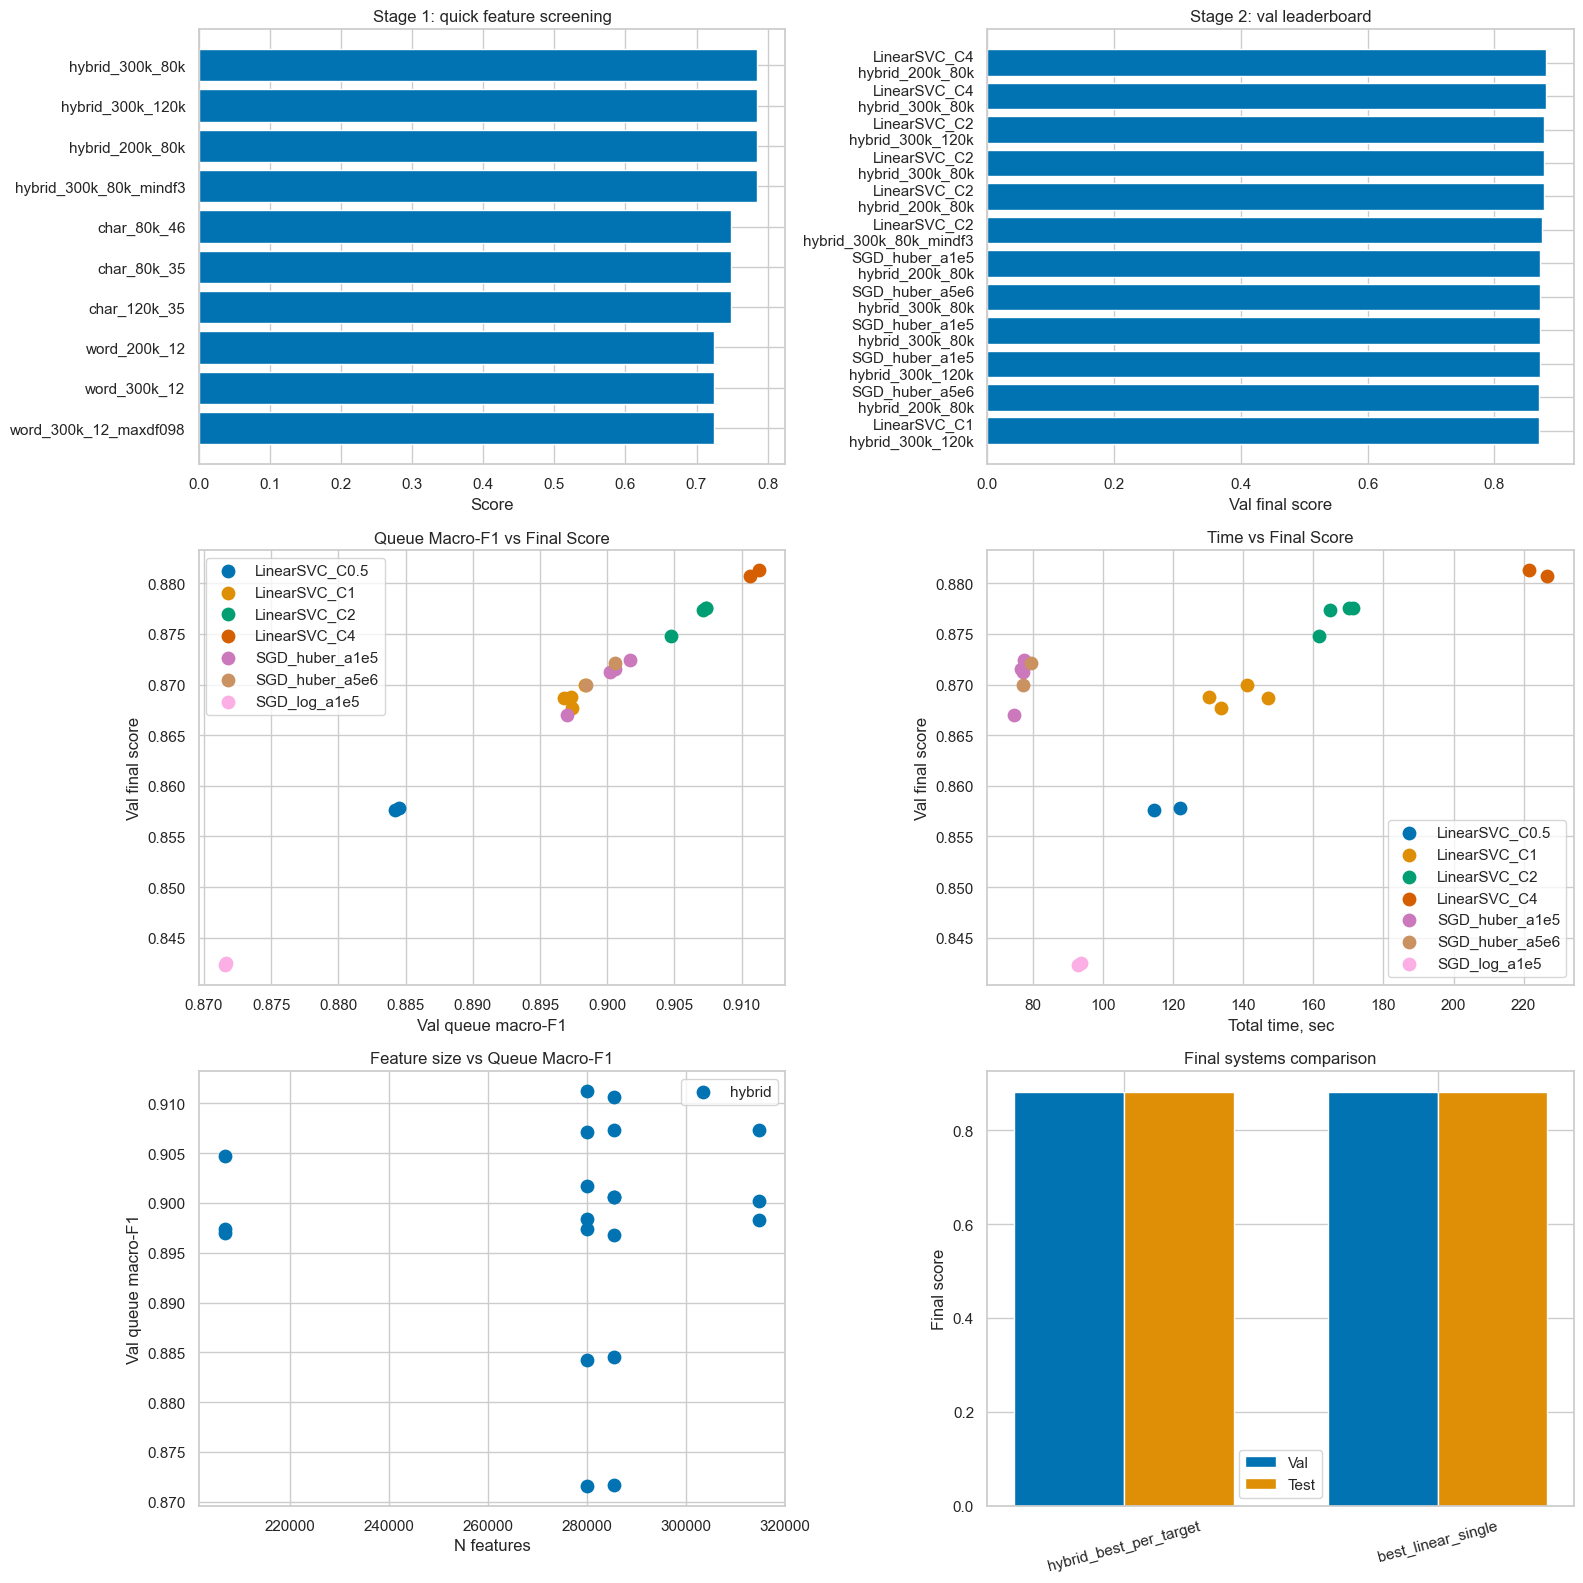

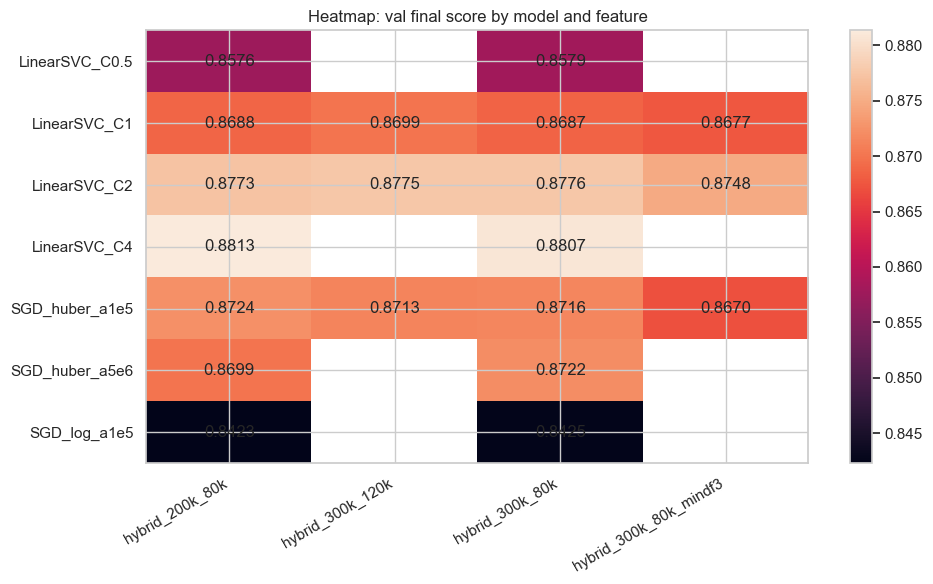

In [21]:
df_results = run_baseline_experiments(dfdicts)

In [22]:
df_results.attrs["summary_table"]

,system,queue_source,priority_source,type_source,val_final_score,val_queue_macro_f1,val_priority_acc,val_type_acc,test_final_score,test_queue_macro_f1,test_priority_acc,test_type_acc
0,hybrid_best_per_target,LinearSVC_C4__hybrid_200k_80k,LinearSVC_C4__hybrid_300k_80k,LinearSVC_C4__hybrid_200k_80k,0.881350,0.911273,0.727655,0.895402,0.882197,0.912748,0.722357,0.899466
1,best_linear_single,LinearSVC_C4__hybrid_200k_80k,LinearSVC_C4__hybrid_200k_80k,LinearSVC_C4__hybrid_200k_80k,0.881325,0.911273,0.727494,0.895402,0.882100,0.912748,0.721710,0.899466


In [27]:
pd.DataFrame(df_results.attrs["best_test_result"], index=[0])

,system,queue_source,priority_source,type_source,val_final_score,val_queue_macro_f1,val_priority_acc,val_type_acc,test_final_score,test_queue_macro_f1,test_priority_acc,test_type_acc
0,hybrid_best_per_target,LinearSVC_C4__hybrid_200k_80k,LinearSVC_C4__hybrid_300k_80k,LinearSVC_C4__hybrid_200k_80k,0.88135,0.911273,0.727655,0.895402,0.882197,0.912748,0.722357,0.899466


In [4]:
def evaluate_best_linear_with_confidence(
    splits: dict[str, pd.DataFrame],
    queue_source: str = "LinearSVC_C4__hybrid_200k_80k",
    priority_source: str = "LinearSVC_C4__hybrid_300k_80k",
    type_source: str = "LinearSVC_C4__hybrid_200k_80k",
    save_dir: str | None = None,
    coverages: list[float] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if save_dir:
        Path(save_dir).mkdir(parents=True, exist_ok=True)

    if coverages is None:
        coverages = [x / 100 for x in range(5, 101, 5)]

    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    def final_score(queue_macro_f1: float, priority_acc: float, type_acc: float) -> float:
        return 0.70 * queue_macro_f1 + 0.15 * priority_acc + 0.15 * type_acc

    def build_word_vectorizer(max_features: int, min_df: int = 2, max_df: float = 0.99):
        return TfidfVectorizer(
            max_features=max_features,
            ngram_range=(1, 2),
            min_df=min_df,
            max_df=max_df,
            sublinear_tf=True,
            strip_accents="unicode",
            lowercase=True,
            norm="l2",
            dtype=np.float32,
        )

    def build_char_vectorizer(max_features: int, ngram_range=(3, 5), min_df: int = 2):
        return TfidfVectorizer(
            analyzer="char_wb",
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            max_df=0.995,
            sublinear_tf=True,
            lowercase=True,
            norm="l2",
            dtype=np.float32,
        )

    def parse_source(source: str):
        model_name, feature_name = source.split("__", 1)
        if feature_name == "word_200k_12":
            cfg = {"name": feature_name, "kind": "word", "word_max_features": 200_000, "word_min_df": 2, "word_max_df": 0.99}
        elif feature_name == "word_300k_12":
            cfg = {"name": feature_name, "kind": "word", "word_max_features": 300_000, "word_min_df": 2, "word_max_df": 0.99}
        elif feature_name == "word_300k_12_mindf3":
            cfg = {"name": feature_name, "kind": "word", "word_max_features": 300_000, "word_min_df": 3, "word_max_df": 0.99}
        elif feature_name == "word_300k_12_maxdf098":
            cfg = {"name": feature_name, "kind": "word", "word_max_features": 300_000, "word_min_df": 2, "word_max_df": 0.98}
        elif feature_name == "char_80k_35":
            cfg = {"name": feature_name, "kind": "char", "char_max_features": 80_000, "char_ngram_range": (3, 5), "char_min_df": 2}
        elif feature_name == "char_120k_35":
            cfg = {"name": feature_name, "kind": "char", "char_max_features": 120_000, "char_ngram_range": (3, 5), "char_min_df": 2}
        elif feature_name == "char_80k_46":
            cfg = {"name": feature_name, "kind": "char", "char_max_features": 80_000, "char_ngram_range": (4, 6), "char_min_df": 2}
        elif feature_name == "hybrid_200k_80k":
            cfg = {"name": feature_name, "kind": "hybrid", "word_max_features": 200_000, "char_max_features": 80_000, "word_min_df": 2, "word_max_df": 0.99, "char_ngram_range": (3, 5), "char_min_df": 2}
        elif feature_name == "hybrid_300k_80k":
            cfg = {"name": feature_name, "kind": "hybrid", "word_max_features": 300_000, "char_max_features": 80_000, "word_min_df": 2, "word_max_df": 0.99, "char_ngram_range": (3, 5), "char_min_df": 2}
        elif feature_name == "hybrid_300k_120k":
            cfg = {"name": feature_name, "kind": "hybrid", "word_max_features": 300_000, "char_max_features": 120_000, "word_min_df": 2, "word_max_df": 0.99, "char_ngram_range": (3, 5), "char_min_df": 2}
        elif feature_name == "hybrid_300k_80k_mindf3":
            cfg = {"name": feature_name, "kind": "hybrid", "word_max_features": 300_000, "char_max_features": 80_000, "word_min_df": 3, "word_max_df": 0.99, "char_ngram_range": (3, 5), "char_min_df": 2}
        else:
            raise ValueError(f"Unknown feature_name: {feature_name}")

        if model_name == "LinearSVC_C0.5":
            model = LinearSVC(C=0.5, class_weight="balanced", max_iter=3000, dual="auto", random_state=42)
        elif model_name == "LinearSVC_C1":
            model = LinearSVC(C=1.0, class_weight="balanced", max_iter=3000, dual="auto", random_state=42)
        elif model_name == "LinearSVC_C2":
            model = LinearSVC(C=2.0, class_weight="balanced", max_iter=3000, dual="auto", random_state=42)
        elif model_name == "LinearSVC_C4":
            model = LinearSVC(C=4.0, class_weight="balanced", max_iter=3000, dual="auto", random_state=42)
        elif model_name == "SGD_huber_a1e5":
            model = SGDClassifier(loss="modified_huber", alpha=1e-5, penalty="l2", max_iter=1500, tol=1e-3, class_weight="balanced", random_state=42)
        elif model_name == "SGD_huber_a5e6":
            model = SGDClassifier(loss="modified_huber", alpha=5e-6, penalty="l2", max_iter=1500, tol=1e-3, class_weight="balanced", random_state=42)
        elif model_name == "SGD_log_a1e5":
            model = SGDClassifier(loss="log_loss", alpha=1e-5, penalty="l2", max_iter=1500, tol=1e-3, class_weight="balanced", random_state=42)
        else:
            raise ValueError(f"Unknown model_name: {model_name}")

        return model_name, feature_name, model, cfg

    def fit_feature_artifact(train_text, val_text, test_text, cfg):
        if cfg["kind"] == "word":
            vec = build_word_vectorizer(
                cfg["word_max_features"],
                min_df=cfg.get("word_min_df", 2),
                max_df=cfg.get("word_max_df", 0.99),
            )
            Xtr = vec.fit_transform(train_text)
            Xva = vec.transform(val_text)
            Xte = vec.transform(test_text)
            return {"kind": "word", "vectorizers": {"word": vec}, "Xtr": Xtr, "Xva": Xva, "Xte": Xte}

        if cfg["kind"] == "char":
            vec = build_char_vectorizer(
                cfg["char_max_features"],
                ngram_range=cfg.get("char_ngram_range", (3, 5)),
                min_df=cfg.get("char_min_df", 2),
            )
            Xtr = vec.fit_transform(train_text)
            Xva = vec.transform(val_text)
            Xte = vec.transform(test_text)
            return {"kind": "char", "vectorizers": {"char": vec}, "Xtr": Xtr, "Xva": Xva, "Xte": Xte}

        word_vec = build_word_vectorizer(
            cfg["word_max_features"],
            min_df=cfg.get("word_min_df", 2),
            max_df=cfg.get("word_max_df", 0.99),
        )
        char_vec = build_char_vectorizer(
            cfg["char_max_features"],
            ngram_range=cfg.get("char_ngram_range", (3, 5)),
            min_df=cfg.get("char_min_df", 2),
        )
        Xtr_word = word_vec.fit_transform(train_text)
        Xva_word = word_vec.transform(val_text)
        Xte_word = word_vec.transform(test_text)
        Xtr_char = char_vec.fit_transform(train_text)
        Xva_char = char_vec.transform(val_text)
        Xte_char = char_vec.transform(test_text)
        Xtr = hstack([Xtr_word, Xtr_char], format="csr")
        Xva = hstack([Xva_word, Xva_char], format="csr")
        Xte = hstack([Xte_word, Xte_char], format="csr")
        return {"kind": "hybrid", "vectorizers": {"word": word_vec, "char": char_vec}, "Xtr": Xtr, "Xva": Xva, "Xte": Xte}

    def softmax(z):
        z = np.asarray(z, dtype=np.float64)
        z = z - z.max(axis=1, keepdims=True)
        ez = np.exp(z)
        return ez / np.clip(ez.sum(axis=1, keepdims=True), 1e-12, None)

    def ensure_2d_scores(scores, classes_):
        scores = np.asarray(scores)
        if scores.ndim == 1:
            scores = np.stack([-scores, scores], axis=1)
            if len(classes_) != 2:
                raise ValueError("Binary scores with classes != 2.")
        return scores

    def encode_y(y, classes_):
        class_to_idx = {c: i for i, c in enumerate(classes_)}
        return np.array([class_to_idx[v] for v in y], dtype=np.int64)

    def nll_with_temperature(scores, y_idx, T):
        probs = softmax(scores / T)
        return -np.mean(np.log(np.clip(probs[np.arange(len(y_idx)), y_idx], 1e-12, 1.0)))

    def fit_temperature(scores_val, y_val, classes_):
        y_idx = encode_y(y_val, classes_)
        grid = np.concatenate([
            np.linspace(0.25, 1.50, 26),
            np.linspace(1.6, 3.0, 15),
            np.linspace(3.5, 8.0, 10),
        ])
        losses = [nll_with_temperature(scores_val, y_idx, T) for T in grid]
        return float(grid[int(np.argmin(losses))])

    def fit_target(source, target, X_train, X_val, X_test, y_train, y_val):
        _, _, model, cfg = parse_source(source)
        artifact = fit_feature_artifact(X_train, X_val, X_test, cfg)
        clf = clone(model)
        clf.fit(artifact["Xtr"], y_train)

        val_scores = ensure_2d_scores(clf.decision_function(artifact["Xva"]), clf.classes_)
        test_scores = ensure_2d_scores(clf.decision_function(artifact["Xte"]), clf.classes_)

        T = fit_temperature(val_scores, y_val, clf.classes_)

        val_probs = softmax(val_scores / T)
        test_probs = softmax(test_scores / T)

        val_pred = clf.classes_[val_probs.argmax(axis=1)]
        test_pred = clf.classes_[test_probs.argmax(axis=1)]

        return {
            "target": target,
            "source": source,
            "model": clf,
            "classes": clf.classes_,
            "temperature": T,
            "val_probs": val_probs,
            "test_probs": test_probs,
            "val_pred": np.asarray(val_pred).astype(str),
            "test_pred": np.asarray(test_pred).astype(str),
            "val_conf": val_probs.max(axis=1),
            "test_conf": test_probs.max(axis=1),
        }

    def score_all(y_true, preds):
        queue_acc = float(accuracy_score(y_true["queue"], preds["queue"]))
        queue_macro_f1 = float(f1_score(y_true["queue"], preds["queue"], average="macro"))
        priority_acc = float(accuracy_score(y_true["priority"], preds["priority"]))
        type_acc = float(accuracy_score(y_true["type"], preds["type"]))
        return {
            "queue_acc": queue_acc,
            "queue_macro_f1": queue_macro_f1,
            "priority_acc": priority_acc,
            "type_acc": type_acc,
            "final_score": float(final_score(queue_macro_f1, priority_acc, type_acc)),
        }

    X_train = make_text(splits["train"])
    X_val = make_text(splits["val"])
    X_test = make_text(splits["test"])

    ytr = {
        "queue": splits["train"]["queue"].astype(str).to_numpy(),
        "priority": splits["train"]["priority"].astype(str).to_numpy(),
        "type": splits["train"]["type"].astype(str).to_numpy(),
    }
    yva = {
        "queue": splits["val"]["queue"].astype(str).to_numpy(),
        "priority": splits["val"]["priority"].astype(str).to_numpy(),
        "type": splits["val"]["type"].astype(str).to_numpy(),
    }
    yte = {
        "queue": splits["test"]["queue"].astype(str).to_numpy(),
        "priority": splits["test"]["priority"].astype(str).to_numpy(),
        "type": splits["test"]["type"].astype(str).to_numpy(),
    }

    start_time = time.perf_counter()

    queue_fit = fit_target(queue_source, "queue", X_train, X_val, X_test, ytr["queue"], yva["queue"])
    priority_fit = fit_target(priority_source, "priority", X_train, X_val, X_test, ytr["priority"], yva["priority"])
    type_fit = fit_target(type_source, "type", X_train, X_val, X_test, ytr["type"], yva["type"])

    train_time_sec = time.perf_counter() - start_time

    val_preds = {
        "queue": queue_fit["val_pred"],
        "priority": priority_fit["val_pred"],
        "type": type_fit["val_pred"],
    }
    test_preds = {
        "queue": queue_fit["test_pred"],
        "priority": priority_fit["test_pred"],
        "type": type_fit["test_pred"],
    }

    val_metrics = score_all(yva, val_preds)
    test_metrics = score_all(yte, test_preds)

    conf_val = 0.70 * queue_fit["val_conf"] + 0.15 * priority_fit["val_conf"] + 0.15 * type_fit["val_conf"]
    conf_test = 0.70 * queue_fit["test_conf"] + 0.15 * priority_fit["test_conf"] + 0.15 * type_fit["test_conf"]

    summary = pd.DataFrame([{
        "system": "best_linear_calibrated",
        "queue_source": queue_source,
        "priority_source": priority_source,
        "type_source": type_source,
        "queue_temperature": queue_fit["temperature"],
        "priority_temperature": priority_fit["temperature"],
        "type_temperature": type_fit["temperature"],
        "val_final_score": val_metrics["final_score"],
        "val_queue_macro_f1": val_metrics["queue_macro_f1"],
        "val_queue_acc": val_metrics["queue_acc"],
        "val_priority_acc": val_metrics["priority_acc"],
        "val_type_acc": val_metrics["type_acc"],
        "test_final_score": test_metrics["final_score"],
        "test_queue_macro_f1": test_metrics["queue_macro_f1"],
        "test_queue_acc": test_metrics["queue_acc"],
        "test_priority_acc": test_metrics["priority_acc"],
        "test_type_acc": test_metrics["type_acc"],
        "train_time_sec": train_time_sec,
    }])

    order = np.argsort(-conf_test)
    n = len(order)
    coverage_rows = []

    for cov in coverages:
        k = max(1, int(round(n * cov)))
        idx_auto = order[:k]
        mask_auto = np.zeros(n, dtype=bool)
        mask_auto[idx_auto] = True
        idx_manual = np.where(~mask_auto)[0]

        auto_preds = {
            "queue": test_preds["queue"][idx_auto],
            "priority": test_preds["priority"][idx_auto],
            "type": test_preds["type"][idx_auto],
        }
        auto_true = {
            "queue": yte["queue"][idx_auto],
            "priority": yte["priority"][idx_auto],
            "type": yte["type"][idx_auto],
        }
        auto_metrics = score_all(auto_true, auto_preds)

        blended_preds = {
            "queue": test_preds["queue"].copy(),
            "priority": test_preds["priority"].copy(),
            "type": test_preds["type"].copy(),
        }
        blended_preds["queue"][idx_manual] = yte["queue"][idx_manual]
        blended_preds["priority"][idx_manual] = yte["priority"][idx_manual]
        blended_preds["type"][idx_manual] = yte["type"][idx_manual]

        blended_metrics = score_all(yte, blended_preds)

        coverage_rows.append({
            "coverage": float(cov),
            "auto_share": float(cov),
            "manual_share": float(1 - cov),
            "n_auto": int(k),
            "n_manual": int(n - k),
            "avg_confidence_auto": float(conf_test[idx_auto].mean()),
            "min_confidence_auto": float(conf_test[idx_auto].min()),
            "auto_queue_macro_f1": auto_metrics["queue_macro_f1"],
            "auto_queue_acc": auto_metrics["queue_acc"],
            "auto_priority_acc": auto_metrics["priority_acc"],
            "auto_type_acc": auto_metrics["type_acc"],
            "auto_final_score": auto_metrics["final_score"],
            "blended_queue_macro_f1": blended_metrics["queue_macro_f1"],
            "blended_queue_acc": blended_metrics["queue_acc"],
            "blended_priority_acc": blended_metrics["priority_acc"],
            "blended_type_acc": blended_metrics["type_acc"],
            "blended_final_score": blended_metrics["final_score"],
        })

    df_coverage = pd.DataFrame(coverage_rows)

    print(summary.to_string(index=False))
    print()
    print(df_coverage.to_string(index=False))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    split_names = ["Val", "Test"]
    final_scores = [summary.loc[0, "val_final_score"], summary.loc[0, "test_final_score"]]
    queue_f1_scores = [summary.loc[0, "val_queue_macro_f1"], summary.loc[0, "test_queue_macro_f1"]]
    priority_scores = [summary.loc[0, "val_priority_acc"], summary.loc[0, "test_priority_acc"]]
    type_scores = [summary.loc[0, "val_type_acc"], summary.loc[0, "test_type_acc"]]

    x = np.arange(len(split_names))
    w = 0.2
    axes[0].bar(x - 1.5 * w, final_scores, w, label="Final score")
    axes[0].bar(x - 0.5 * w, queue_f1_scores, w, label="Queue Macro-F1")
    axes[0].bar(x + 0.5 * w, priority_scores, w, label="Priority Acc")
    axes[0].bar(x + 1.5 * w, type_scores, w, label="Type Acc")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(split_names)
    axes[0].set_ylim(0, 1)
    axes[0].set_title("Calibrated best linear model")
    axes[0].legend()

    axes[1].plot(df_coverage["auto_share"], df_coverage["auto_final_score"], marker="o", label="Auto-only Final score")
    axes[1].plot(df_coverage["auto_share"], df_coverage["auto_queue_macro_f1"], marker="s", label="Auto-only Queue Macro-F1")
    axes[1].plot(df_coverage["auto_share"], df_coverage["auto_priority_acc"], marker="^", label="Auto-only Priority Acc")
    axes[1].plot(df_coverage["auto_share"], df_coverage["auto_type_acc"], marker="d", label="Auto-only Type Acc")
    axes[1].set_ylim(0, 1)
    axes[1].set_xlabel("Auto share")
    axes[1].set_title("Quality on auto-processed subset")
    axes[1].legend()

    axes[2].plot(df_coverage["auto_share"], df_coverage["blended_final_score"], marker="o", label="Blended Final score")
    axes[2].plot(df_coverage["auto_share"], df_coverage["blended_queue_macro_f1"], marker="s", label="Blended Queue Macro-F1")
    axes[2].plot(df_coverage["auto_share"], df_coverage["blended_priority_acc"], marker="^", label="Blended Priority Acc")
    axes[2].plot(df_coverage["auto_share"], df_coverage["blended_type_acc"], marker="d", label="Blended Type Acc")
    axes[2].set_ylim(0, 1)
    axes[2].set_xlabel("Auto share")
    axes[2].set_title("Overall quality if manual part is perfect")
    axes[2].legend()

    plt.tight_layout()

    if save_dir:
        summary.to_csv(Path(save_dir) / "best_linear_calibrated_summary.csv", index=False)
        df_coverage.to_csv(Path(save_dir) / "best_linear_calibrated_confidence_coverage.csv", index=False)
        plt.savefig(Path(save_dir) / "best_linear_calibrated_confidence_analysis.png", dpi=200, bbox_inches="tight")

    plt.show()
    plt.close()

    return summary, df_coverage

In [5]:
def plot_best_linear_confidence_results(
    summary: pd.DataFrame,
    df_coverage: pd.DataFrame,
    save_path: str | None = None,
):
    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    split_names = ["Val", "Test"]
    final_scores = [summary.loc[0, "val_final_score"], summary.loc[0, "test_final_score"]]
    queue_f1_scores = [summary.loc[0, "val_queue_macro_f1"], summary.loc[0, "test_queue_macro_f1"]]
    queue_acc_scores = [summary.loc[0, "val_queue_acc"], summary.loc[0, "test_queue_acc"]]
    priority_scores = [summary.loc[0, "val_priority_acc"], summary.loc[0, "test_priority_acc"]]
    type_scores = [summary.loc[0, "val_type_acc"], summary.loc[0, "test_type_acc"]]

    x = np.arange(len(split_names))
    w = 0.16

    axes[0, 0].bar(x - 2 * w, final_scores, w, label="Final score")
    axes[0, 0].bar(x - 1 * w, queue_f1_scores, w, label="Queue Macro-F1")
    axes[0, 0].bar(x + 0 * w, queue_acc_scores, w, label="Queue Acc")
    axes[0, 0].bar(x + 1 * w, priority_scores, w, label="Priority Acc")
    axes[0, 0].bar(x + 2 * w, type_scores, w, label="Type Acc")
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(split_names)
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].set_title("Best calibrated linear model: Val vs Test")
    axes[0, 0].set_ylabel("Metric")
    axes[0, 0].grid(axis="y", alpha=0.3)
    axes[0, 0].legend()

    axes[0, 1].plot(df_coverage["auto_share"], df_coverage["auto_final_score"], marker="o", label="Auto-only Final score")
    axes[0, 1].plot(df_coverage["auto_share"], df_coverage["auto_queue_macro_f1"], marker="s", label="Auto-only Queue Macro-F1")
    axes[0, 1].plot(df_coverage["auto_share"], df_coverage["auto_priority_acc"], marker="^", label="Auto-only Priority Acc")
    axes[0, 1].plot(df_coverage["auto_share"], df_coverage["auto_type_acc"], marker="d", label="Auto-only Type Acc")
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].set_xlabel("Auto share")
    axes[0, 1].set_ylabel("Metric")
    axes[0, 1].set_title("Quality on auto-processed subset")
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].legend()

    axes[1, 0].plot(df_coverage["manual_share"], df_coverage["blended_final_score"], marker="o", label="Blended Final score")
    axes[1, 0].plot(df_coverage["manual_share"], df_coverage["blended_queue_macro_f1"], marker="s", label="Blended Queue Macro-F1")
    axes[1, 0].plot(df_coverage["manual_share"], df_coverage["blended_priority_acc"], marker="^", label="Blended Priority Acc")
    axes[1, 0].plot(df_coverage["manual_share"], df_coverage["blended_type_acc"], marker="d", label="Blended Type Acc")
    axes[1, 0].set_ylim(0, 1)
    axes[1, 0].set_xlabel("Manual share")
    axes[1, 0].set_ylabel("Metric")
    axes[1, 0].set_title("Overall quality if manual part is perfect")
    axes[1, 0].grid(alpha=0.3)
    axes[1, 0].legend()

    ax = axes[1, 1]
    ax.plot(df_coverage["auto_share"], df_coverage["avg_confidence_auto"], marker="o", label="Avg confidence")
    ax.plot(df_coverage["auto_share"], df_coverage["min_confidence_auto"], marker="s", label="Min confidence in auto subset")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Auto share")
    ax.set_ylabel("Confidence")
    ax.set_title("Confidence profile by coverage")
    ax.grid(alpha=0.3)
    ax.legend()

    row70 = df_coverage.loc[np.isclose(df_coverage["auto_share"], 0.70)]
    if len(row70) > 0:
        row70 = row70.iloc[0]

        axes[0, 1].axvline(0.70, linestyle="--", alpha=0.8)
        axes[1, 0].axvline(0.30, linestyle="--", alpha=0.8)
        axes[1, 1].axvline(0.70, linestyle="--", alpha=0.8)

        axes[0, 1].scatter([0.70], [row70["auto_final_score"]], s=120, zorder=5)
        axes[1, 0].scatter([0.30], [row70["blended_final_score"]], s=120, zorder=5)
        axes[1, 1].scatter([0.70], [row70["avg_confidence_auto"]], s=120, zorder=5)

        axes[0, 1].text(
            0.70,
            row70["auto_final_score"],
            f" 70/30\n score={row70['auto_final_score']:.3f}",
            va="bottom",
        )
        axes[1, 0].text(
            0.30,
            row70["blended_final_score"],
            f" 30% manual\n score={row70['blended_final_score']:.3f}",
            va="bottom",
        )
        axes[1, 1].text(
            0.70,
            row70["avg_confidence_auto"],
            f" conf={row70['avg_confidence_auto']:.3f}",
            va="bottom",
        )

    plt.suptitle("Confidence-based analysis for best linear system", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close()

In [8]:
def plot_manual_review_tradeoff(
    df_coverage: pd.DataFrame,
    save_path: str | None = None,
):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(df_coverage["manual_share"], df_coverage["blended_final_score"], marker="o", linewidth=2, label="Final score")
    ax.plot(df_coverage["manual_share"], df_coverage["blended_queue_macro_f1"], marker="s", linewidth=2, label="Queue Macro-F1")

    row70 = df_coverage.loc[np.isclose(df_coverage["auto_share"], 0.70)]
    if len(row70) > 0:
        row70 = row70.iloc[0]
        ax.axvline(row70["manual_share"], linestyle="--", alpha=0.8)
        ax.scatter([row70["manual_share"]], [row70["blended_final_score"]], s=120, zorder=5)
        ax.text(
            row70["manual_share"],
            row70["blended_final_score"],
            f" 70% auto / 30% manual\n Final score={row70['blended_final_score']:.4f}",
            va="bottom",
        )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Manual share")
    ax.set_ylabel("Metric")
    ax.set_title("Quality gain from manual review")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close()

                system                  queue_source               priority_source                   type_source  queue_temperature  priority_temperature  type_temperature  val_final_score  val_queue_macro_f1  val_queue_acc  val_priority_acc  val_type_acc  test_final_score  test_queue_macro_f1  test_queue_acc  test_priority_acc  test_type_acc  train_time_sec
best_linear_calibrated LinearSVC_C4__hybrid_200k_80k LinearSVC_C4__hybrid_300k_80k LinearSVC_C4__hybrid_200k_80k               0.25                  0.55               0.5          0.88135            0.911273       0.691548          0.727655      0.895402          0.882197             0.912748        0.695645           0.722357       0.899466      266.723766

 coverage  auto_share  manual_share  n_auto  n_manual  avg_confidence_auto  min_confidence_auto  auto_queue_macro_f1  auto_queue_acc  auto_priority_acc  auto_type_acc  auto_final_score  blended_queue_macro_f1  blended_queue_acc  blended_priority_acc  blended_type_acc  blended_

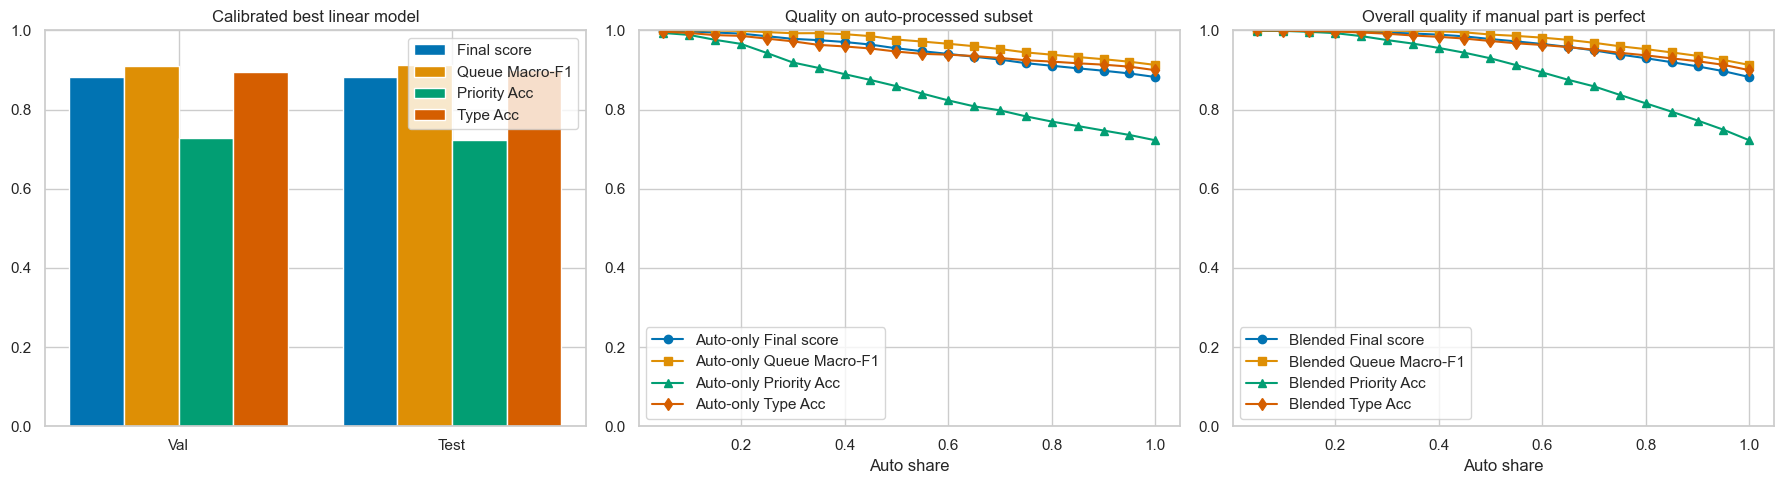

In [6]:
summary_calibrated, coverage_calibrated = evaluate_best_linear_with_confidence(
    splits=dfdicts,
    queue_source="LinearSVC_C4__hybrid_200k_80k",
    priority_source="LinearSVC_C4__hybrid_300k_80k",
    type_source="LinearSVC_C4__hybrid_200k_80k",
    save_dir="results_best_linear_confidence",
)

In [7]:
coverage_calibrated[coverage_calibrated["coverage"].round(2) == 0.70]

,coverage,auto_share,manual_share,n_auto,n_manual,avg_confidence_auto,min_confidence_auto,auto_queue_macro_f1,auto_queue_acc,auto_priority_acc,auto_type_acc,auto_final_score,blended_queue_macro_f1,blended_queue_acc,blended_priority_acc,blended_type_acc,blended_final_score
13,0.7,0.7,0.3,4324,1853,0.821214,0.537239,0.952955,0.838575,0.798104,0.930389,0.926342,0.968731,0.887,0.858669,0.951271,0.949603


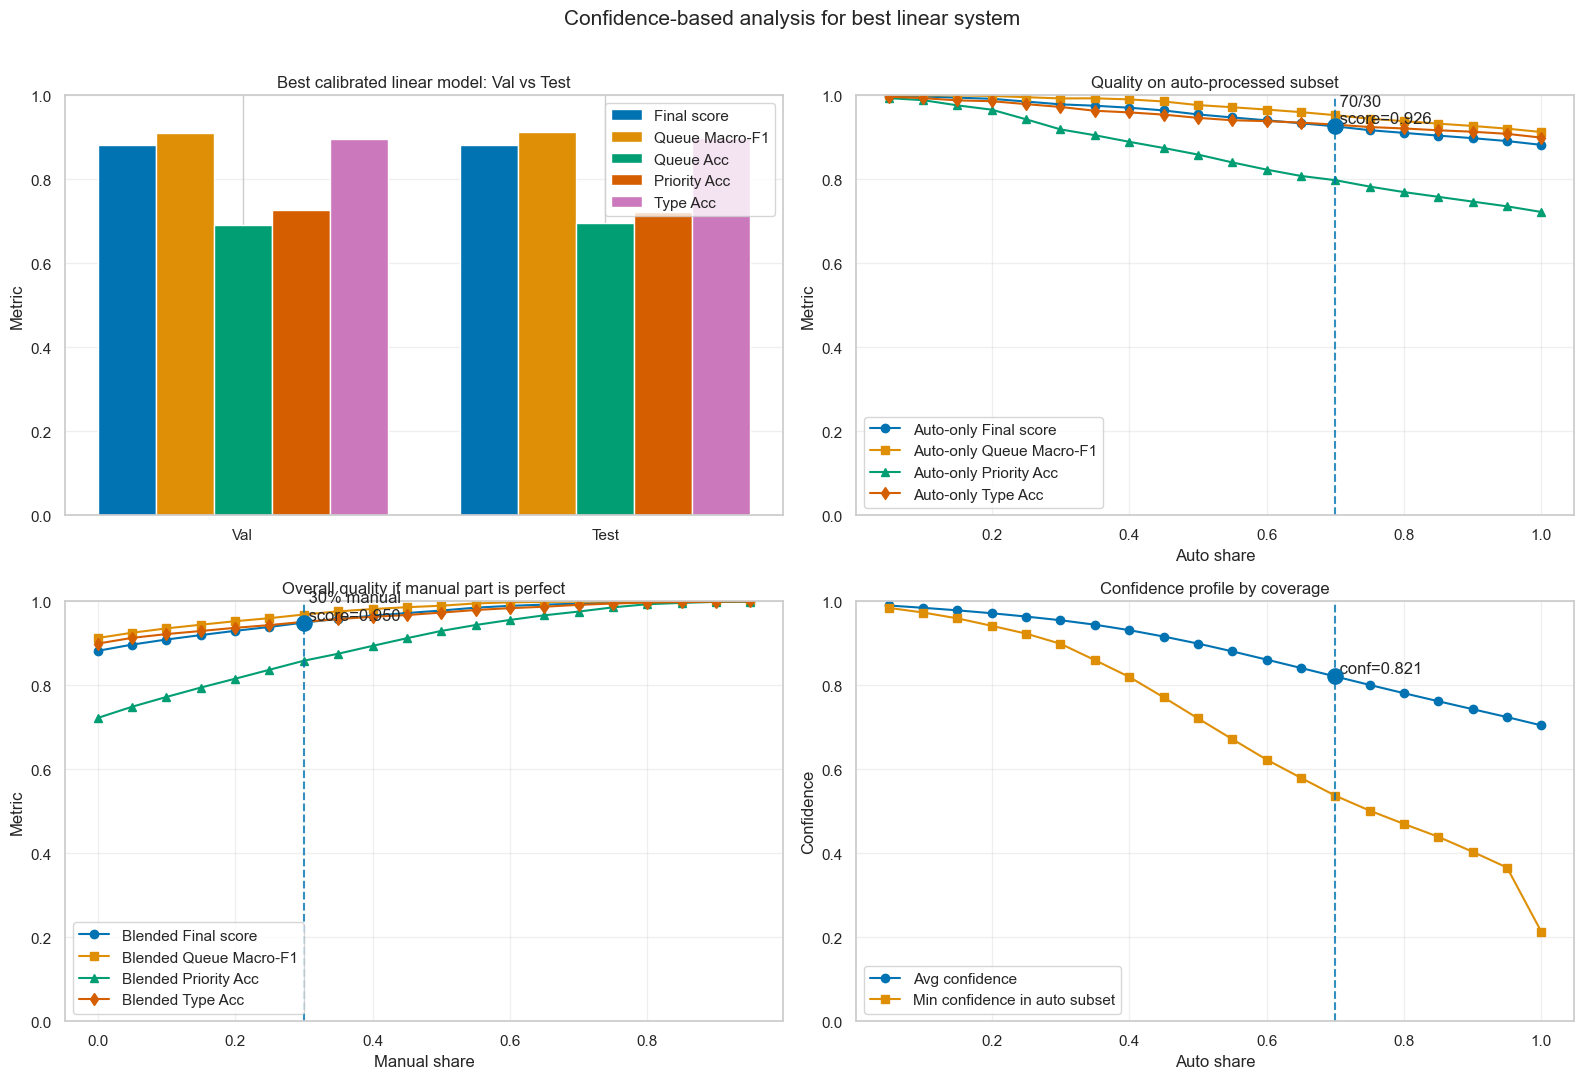

In [11]:
plot_best_linear_confidence_results(
    summary=summary_calibrated,
    df_coverage=coverage_calibrated,
    save_path=None,
)

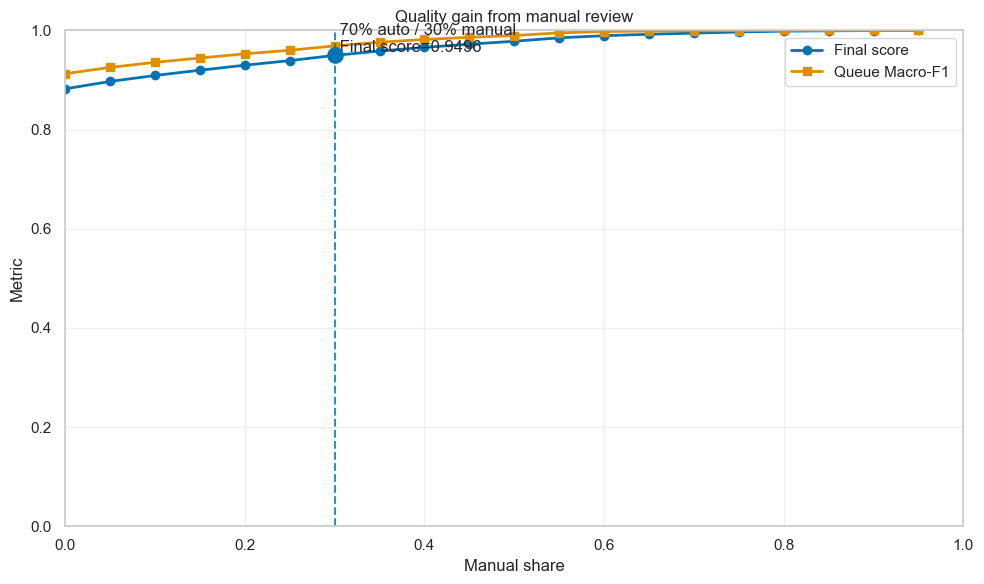

In [10]:
plot_manual_review_tradeoff(
    df_coverage=coverage_calibrated,
    save_path=None,
)

На графике видим, что Final score: 0.9496

## Вывод про уверенность (confidence)


1. Модель показывает очень сильное базовое качество без дополнительных фильтров. На тесте итоговый score около 0.88, при этом основная задача маршрутизации (queue) решается особенно хорошо — Macro-F1 ≈ 0.91.

2. Калибровка уверенности не изменила сами предсказания, но позволила упорядочить их по надежности. Благодаря этому можно выбирать только самые уверенные предсказания для автоматической обработки.

3. Самые уверенные тикеты модель решает почти без ошибок. Например, если брать только 10-20% самых уверенных, качество на них практически идеальное.

4. Если автоматически обрабатывать 70% самых уверенных тикетов, качество на этой автоматической части становится заметно выше общего качества модели. Это означает, что модель хорошо понимает, где она уверена, а где нет.

5. Если оставшиеся 30% сложных тикетов отправлять на ручную обработку, итоговое качество всей системы становится значительно выше. В таком сценарии итоговый score приближается к 0.95.

6. Даже небольшая доля ручной проверки дает заметный эффект. Например, если проверять вручную всего 10–20% тикетов, общее качество системы уже заметно растет.

7. Основная задача маршрутизации (queue) уже решается очень надежно. Основные ошибки возникают в определении priority, поэтому ручная проверка особенно помогает именно этой части.

8. Практически оптимальный баланс выглядит как 70–80% автоматической обработки и 20–30% ручной, потому что при этом сохраняется большое покрытие, но итоговое качество становится значительно выше.

# Transformer multitask baseline

Здесь построил единую multitask-модель на трансформере.

В качестве энкодера (для задачи FE) берется xlm-roberta-base т.к. в датасете есть английские и немецкие тикеты. Модель получает один и тот же текстовый вход и одновременно решает три задачи:

Сначала текст каждого тикета собирается из subject и body: subject + "\n\n" + body.

Текст токенизируется через AutoTokenizer для xlm-roberta-base, с ограничением длины max_length=384 (работаю с контекстными эмбеддингами трансформера)

Создал multitask-архитектуру:
1) общий encoder XLM-RoBERTa,
2) три отдельные классификационные головы (каждая голова — это небольшой MLP-блок: dropout -> linear -> GELU -> dropout -> linear):
  - для queue
  - для priority
  - для type

Замораживается почти весь backbone, а размораживаются только последние 4 слоя энкодера. Для разных частей модели задал разные learning rate. Использовал layer-wise learning rate decay = 0.9, чтобы fine-tuning был стабильнее.

Для queue используются:
  - class_weight="balanced" через веса классов,
  - label_smoothing_queue=0.05.

т.к. исходя из EDA именно queue была самой несбалансированной задачей.

Общая функция потерь — это взвешенная сумма трех loss:
  - queue_loss_weight = 0.84
  - priority_loss_weight = 0.08
  - type_loss_weight = 0.08

По эпохам видно, что модель обучается стабильно:
  - Val Score растет от 0.6189 на 1 эпохе
  - до лучшего значения 0.8462 на 14 эпохе
  - на 15 эпохе уже есть легкая стагнация/незначительное ухудшение (0.8448)

Для xlm-roberta-base получено:
  - queue_acc = 0.5699
  - queue_macro_f1 = 0.8845
  - priority_acc = 0.6073
  - type_acc = 0.8664
  - final_score = 0.8402

Вывод: Для данного датасета линейная модель на хорошо подобранных word + char TF-IDF признаках оказалась сильнее, чем multitask fine-tuning xlm-roberta-base.

In [ ]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

warnings.filterwarnings("ignore")


def baseline_transformer_multitask(
    splits: dict[str, pd.DataFrame],
    save_dir: str | None = None,
    model_name: str = "xlm-roberta-base",
    num_epochs: int = 15,
    batch_size: int = 256,
    learning_rate_head: float = 2e-4,
    learning_rate_encoder: float = 2e-5,
    max_length: int = 450,
    weight_decay: float = 0.01,
    warmup_ratio: float = 0.1,
    unfreeze_last_n_layers: int = 6,
    layerwise_lr_decay: float = 0.9,
    dropout: float = 0.3,
    queue_loss_weight: float = 0.80,
    priority_loss_weight: float = 0.1,
    type_loss_weight: float = 0.1,
    label_smoothing_queue: float = 0.05,
) -> pd.DataFrame:
    if save_dir:
        Path(save_dir).mkdir(parents=True, exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    use_amp = torch.cuda.is_available()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    print(f"Device: {device}")

    def make_text(d: pd.DataFrame) -> list[str]:
        return f"[LANGUAGE = {d['language'].iloc[0]}] {(d['subject'].fillna('') + '\n\n' + d['body'].fillna('')).astype(str).tolist()}"

    class MultiTaskDataset(Dataset):
        def __init__(self, texts, labels_queue, labels_priority, labels_type):
            self.texts = texts
            self.labels_queue = labels_queue
            self.labels_priority = labels_priority
            self.labels_type = labels_type

        def __len__(self):
            return len(self.texts)

        def __getitem__(self, idx):
            return {
                "text": self.texts[idx],
                "labels_queue": int(self.labels_queue[idx]),
                "labels_priority": int(self.labels_priority[idx]),
                "labels_type": int(self.labels_type[idx]),
            }

    class Collator:
        def __init__(self, tokenizer, max_length):
            self.tokenizer = tokenizer
            self.max_length = max_length

        def __call__(self, batch):
            texts = [x["text"] for x in batch]
            enc = self.tokenizer(
                texts,
                add_special_tokens=True,
                truncation=True,
                max_length=self.max_length,
                padding=True,
                return_tensors="pt",
            )
            return {
                "input_ids": enc["input_ids"],
                "attention_mask": enc["attention_mask"],
                "labels_queue": torch.tensor([x["labels_queue"] for x in batch], dtype=torch.long),
                "labels_priority": torch.tensor([x["labels_priority"] for x in batch], dtype=torch.long),
                "labels_type": torch.tensor([x["labels_type"] for x in batch], dtype=torch.long),
            }

    class ClsHead(nn.Module):
        def __init__(self, hidden_size, out_dim, dropout):
            super().__init__()
            self.dropout1 = nn.Dropout(dropout)
            self.dense = nn.Linear(hidden_size, hidden_size)
            self.act = nn.GELU()
            self.dropout2 = nn.Dropout(dropout)
            self.out_proj = nn.Linear(hidden_size, out_dim)

        def forward(self, x):
            x = self.dropout1(x)
            x = self.dense(x)
            x = self.act(x)
            x = self.dropout2(x)
            return self.out_proj(x)

    class MultiTaskTransformer(nn.Module):
        def __init__(self, model_name, num_queue, num_priority, num_type, dropout=0.3):
            super().__init__()
            self.backbone = AutoModel.from_pretrained(model_name)
            if hasattr(self.backbone, "gradient_checkpointing_enable"):
                self.backbone.gradient_checkpointing_enable()
            hidden_size = self.backbone.config.hidden_size
            self.queue_head = ClsHead(hidden_size, num_queue, dropout)
            self.priority_head = ClsHead(hidden_size, num_priority, dropout)
            self.type_head = ClsHead(hidden_size, num_type, dropout)

        def forward(self, input_ids, attention_mask):
            outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
            cls = outputs.last_hidden_state[:, 0, :]
            queue_logits = self.queue_head(cls)
            priority_logits = self.priority_head(cls)
            type_logits = self.type_head(cls)
            return queue_logits, priority_logits, type_logits

    def freeze_backbone_except_last_n(model, last_n):
        for p in model.backbone.parameters():
            p.requires_grad = False

        if hasattr(model.backbone, "embeddings"):
            for p in model.backbone.embeddings.parameters():
                p.requires_grad = False

        layers = None
        if hasattr(model.backbone, "encoder") and hasattr(model.backbone.encoder, "layer"):
            layers = model.backbone.encoder.layer
        elif hasattr(model.backbone, "roberta") and hasattr(model.backbone.roberta, "encoder"):
            layers = model.backbone.roberta.encoder.layer

        if layers is not None:
            for layer in layers[-last_n:]:
                for p in layer.parameters():
                    p.requires_grad = True

        for p in model.queue_head.parameters():
            p.requires_grad = True
        for p in model.priority_head.parameters():
            p.requires_grad = True
        for p in model.type_head.parameters():
            p.requires_grad = True

    def build_optimizer(model):
        no_decay = ["bias", "LayerNorm.bias", "LayerNorm.weight"]

        layers = model.backbone.encoder.layer
        param_groups = []

        head_params_decay = []
        head_params_nodecay = []
        for n, p in list(model.queue_head.named_parameters()) + list(model.priority_head.named_parameters()) + list(model.type_head.named_parameters()):
            if not p.requires_grad:
                continue
            if any(nd in n for nd in no_decay):
                head_params_nodecay.append(p)
            else:
                head_params_decay.append(p)

        if head_params_decay:
            param_groups.append({"params": head_params_decay, "lr": learning_rate_head, "weight_decay": weight_decay})
        if head_params_nodecay:
            param_groups.append({"params": head_params_nodecay, "lr": learning_rate_head, "weight_decay": 0.0})

        trainable_layers = layers[-unfreeze_last_n_layers:]
        n_trainable = len(trainable_layers)

        for i, layer in enumerate(trainable_layers):
            lr = learning_rate_encoder * (layerwise_lr_decay  (n_trainable - 1 - i))
            layer_decay_params = []
            layer_nodecay_params = []
            for n, p in layer.named_parameters():
                if not p.requires_grad:
                    continue
                if any(nd in n for nd in no_decay):
                    layer_nodecay_params.append(p)
                else:
                    layer_decay_params.append(p)

            if layer_decay_params:
                param_groups.append({"params": layer_decay_params, "lr": lr, "weight_decay": weight_decay})
            if layer_nodecay_params:
                param_groups.append({"params": layer_nodecay_params, "lr": lr, "weight_decay": 0.0})

        return torch.optim.AdamW(param_groups)

    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

    X_train = make_text(splits["train"])
    X_val = make_text(splits["val"])
    X_test = make_text(splits["test"])

    le_queue = LabelEncoder()
    le_priority = LabelEncoder()
    le_type = LabelEncoder()

    ytr_queue = le_queue.fit_transform(splits["train"]["queue"].astype(str).to_numpy())
    ytr_priority = le_priority.fit_transform(splits["train"]["priority"].astype(str).to_numpy())
    ytr_type = le_type.fit_transform(splits["train"]["type"].astype(str).to_numpy())

    yvl_queue = le_queue.transform(splits["val"]["queue"].astype(str).to_numpy())
    yvl_priority = le_priority.transform(splits["val"]["priority"].astype(str).to_numpy())
    yvl_type = le_type.transform(splits["val"]["type"].astype(str).to_numpy())

    yte_queue = le_queue.transform(splits["test"]["queue"].astype(str).to_numpy())
    yte_priority = le_priority.transform(splits["test"]["priority"].astype(str).to_numpy())
    yte_type = le_type.transform(splits["test"]["type"].astype(str).to_numpy())

    num_queue = len(le_queue.classes_)
    num_priority = len(le_priority.classes_)
    num_type = len(le_type.classes_)

    print(f"Classes: queue={num_queue}, priority={num_priority}, type={num_type}")

    queue_classes = np.unique(ytr_queue)
    queue_class_weights = compute_class_weight(class_weight="balanced", classes=queue_classes, y=ytr_queue)
    queue_class_weights = torch.tensor(queue_class_weights, dtype=torch.float32, device=device)

    train_dataset = MultiTaskDataset(X_train, ytr_queue, ytr_priority, ytr_type)
    val_dataset = MultiTaskDataset(X_val, yvl_queue, yvl_priority, yvl_type)
    test_dataset = MultiTaskDataset(X_test, yte_queue, yte_priority, yte_type)

    collator = Collator(tokenizer, max_length=max_length)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collator,
        persistent_workers=False,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collator,
        persistent_workers=False,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        collate_fn=collator,
        persistent_workers=False,
    )

    print(f"\nInitializing model: {model_name}")
    model = MultiTaskTransformer(model_name, num_queue, num_priority, num_type, dropout=dropout).to(device)
    freeze_backbone_except_last_n(model, unfreeze_last_n_layers)

    criterion_queue = nn.CrossEntropyLoss(weight=queue_class_weights, label_smoothing=label_smoothing_queue)
    criterion_priority = nn.CrossEntropyLoss()
    criterion_type = nn.CrossEntropyLoss()

    optimizer = build_optimizer(model)
    total_steps = len(train_loader) * num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(warmup_ratio * total_steps),
        num_training_steps=total_steps,
    )
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    print(f"\nTraining on {device} for {num_epochs} epochs...")
    start_time = time.time()

    best_val_score = -1.0
    best_model_state = None
    history = {"train_loss": [], "val_score": []}

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)
            labels_queue = batch["labels_queue"].to(device, non_blocking=True)
            labels_priority = batch["labels_priority"].to(device, non_blocking=True)
            labels_type = batch["labels_type"].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                queue_logits, priority_logits, type_logits = model(input_ids, attention_mask)
                loss_queue = criterion_queue(queue_logits, labels_queue)
                loss_priority = criterion_priority(priority_logits, labels_priority)
                loss_type = criterion_type(type_logits, labels_type)
                loss = (
                    queue_loss_weight * loss_queue
                    + priority_loss_weight * loss_priority
                    + type_loss_weight * loss_type
                )

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            total_loss += loss.item()

        model.eval()
        all_queue_pred, all_queue_true = [], []
        all_priority_pred, all_priority_true = [], []
        all_type_pred, all_type_true = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device, non_blocking=True)
                attention_mask = batch["attention_mask"].to(device, non_blocking=True)
                labels_queue = batch["labels_queue"].to(device, non_blocking=True)
                labels_priority = batch["labels_priority"].to(device, non_blocking=True)
                labels_type = batch["labels_type"].to(device, non_blocking=True)

                with torch.cuda.amp.autocast(enabled=use_amp):
                    queue_logits, priority_logits, type_logits = model(input_ids, attention_mask)

                all_queue_pred.extend(queue_logits.argmax(dim=1).cpu().numpy())
                all_queue_true.extend(labels_queue.cpu().numpy())
                all_priority_pred.extend(priority_logits.argmax(dim=1).cpu().numpy())
                all_priority_true.extend(labels_priority.cpu().numpy())
                all_type_pred.extend(type_logits.argmax(dim=1).cpu().numpy())
                all_type_true.extend(labels_type.cpu().numpy())

        val_queue_f1 = f1_score(all_queue_true, all_queue_pred, average="macro")
        val_priority_acc = accuracy_score(all_priority_true, all_priority_pred)
        val_type_acc = accuracy_score(all_type_true, all_type_pred)
        val_score = 0.70 * val_queue_f1 + 0.15 * val_priority_acc + 0.15 * val_type_acc

        epoch_train_loss = total_loss / max(len(train_loader), 1)
        history["train_loss"].append(epoch_train_loss)
        history["val_score"].append(val_score)

        if val_score > best_val_score:
            best_val_score = val_score
            best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch + 1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f}, Val Score: {val_score:.4f}")

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model.to(device)

    print("\nEvaluating on test set...")
    infer_start = time.time()
    model.eval()
    all_queue_pred, all_priority_pred, all_type_pred = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device, non_blocking=True)
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                queue_logits, priority_logits, type_logits = model(input_ids, attention_mask)

            all_queue_pred.extend(queue_logits.argmax(dim=1).cpu().numpy())
            all_priority_pred.extend(priority_logits.argmax(dim=1).cpu().numpy())
            all_type_pred.extend(type_logits.argmax(dim=1).cpu().numpy())

    infer_time = time.time() - infer_start
    total_time = time.time() - start_time

    peak_memory_mb = torch.cuda.max_memory_allocated(device) / 1024 / 1024 if torch.cuda.is_available() else np.nan

    queue_acc = accuracy_score(yte_queue, all_queue_pred)
    queue_f1 = f1_score(yte_queue, all_queue_pred, average="macro")
    priority_acc = accuracy_score(yte_priority, all_priority_pred)
    type_acc = accuracy_score(yte_type, all_type_pred)
    final_score = 0.70 * queue_f1 + 0.15 * priority_acc + 0.15 * type_acc

    results = {
        "model": "Transformer_MultiTask_Better",
        "base_model": model_name,
        "epochs": num_epochs,
        "batch_size": batch_size,
        "learning_rate_head": learning_rate_head,
        "learning_rate_encoder": learning_rate_encoder,
        "max_length": max_length,
        "unfreeze_last_n_layers": unfreeze_last_n_layers,
        "layerwise_lr_decay": layerwise_lr_decay,
        "queue_acc": queue_acc,
        "queue_macro_f1": queue_f1,
        "priority_acc": priority_acc,
        "type_acc": type_acc,
        "final_score": final_score,
        "train_time_sec": total_time - infer_time,
        "infer_time_sec": infer_time,
        "total_time_sec": total_time,
        "peak_memory_mb": peak_memory_mb,
        "num_params": sum(p.numel() for p in model.parameters()),
        "best_val_score": best_val_score,
    }

    df_results = pd.DataFrame([results])

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    metrics = ["queue_macro_f1", "priority_acc", "type_acc"]
    metric_names = ["Queue Macro F1", "Priority Acc", "Type Acc"]

    for ax, metric, name in zip([axes[0, 0], axes[0, 1], axes[1, 0]], metrics, metric_names):
        ax.bar([name], [results[metric]])
        ax.set_ylim(0, 1)
        ax.set_title(f"{name}: {results[metric]:.4f}")
        ax.grid(axis="y", alpha=0.3)

    axes[1, 1].plot(range(1, num_epochs + 1), history["train_loss"], marker="o", label="Train Loss")
    axes[1, 1].plot(range(1, num_epochs + 1), history["val_score"], marker="s", label="Val Score")
    axes[1, 1].axhline(best_val_score, linestyle="--", label=f"Best Val: {best_val_score:.4f}")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_title("Training History")
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    if save_dir:
        plt.savefig(Path(save_dir) / "transformer_multitask_better_performance.png", dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()

    print("\n" + "=" * 80)
    print("TRANSFORMER MULTITASK BETTER SUMMARY")
    print("=" * 80)
    print(f"\nModel: {model_name}")
    print(f"Device: {device}")
    print(f"Parameters: {results['num_params']:,}")
    print(f"\nTraining: {results['train_time_sec']:.2f}s, Inference: {results['infer_time_sec']:.2f}s, Total: {results['total_time_sec']:.2f}s")
    print(f"Peak Memory: {'n/a (CPU)' if np.isnan(results['peak_memory_mb']) else f'{results['peak_memory_mb']:.2f}MB'}")
    print(f"\nResults:")
    print(f"  Queue:     Acc={queue_acc:.4f}, Macro F1={queue_f1:.4f}")
    print(f"  Priority:  Acc={priority_acc:.4f}")
    print(f"  Type:      Acc={type_acc:.4f}")
    print(f"\nFINAL SCORE: {final_score:.4f}")
    print(f"\nBest Validation Score: {best_val_score:.4f}")
    print("=" * 80)

    if save_dir:
        df_results.to_csv(Path(save_dir) / "transformer_multitask_better_results.csv", index=False)
        torch.save(best_model_state, Path(save_dir) / "model_checkpoint_better.pt")
        print(f"\nResults saved to {save_dir}/")

    return df_results

Device: cuda
Classes: queue=52, priority=5, type=5

Initializing model: xlm-roberta-base


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Training on cuda for 15 epochs...
Epoch 1/15 - Train Loss: 3.1614, Val Score: 0.6189
Epoch 2/15 - Train Loss: 1.9002, Val Score: 0.7252
Epoch 3/15 - Train Loss: 1.6155, Val Score: 0.7711
Epoch 4/15 - Train Loss: 1.5116, Val Score: 0.7868
Epoch 5/15 - Train Loss: 1.4552, Val Score: 0.7972
Epoch 6/15 - Train Loss: 1.3901, Val Score: 0.8100
Epoch 7/15 - Train Loss: 1.3688, Val Score: 0.8124
Epoch 8/15 - Train Loss: 1.3208, Val Score: 0.8214
Epoch 9/15 - Train Loss: 1.2710, Val Score: 0.8276
Epoch 10/15 - Train Loss: 1.2699, Val Score: 0.8297
Epoch 11/15 - Train Loss: 1.2462, Val Score: 0.8365
Epoch 12/15 - Train Loss: 1.2331, Val Score: 0.8397
Epoch 13/15 - Train Loss: 1.2243, Val Score: 0.8451
Epoch 14/15 - Train Loss: 1.2023, Val Score: 0.8462
Epoch 15/15 - Train Loss: 1.2104, Val Score: 0.8448

Evaluating on test set...


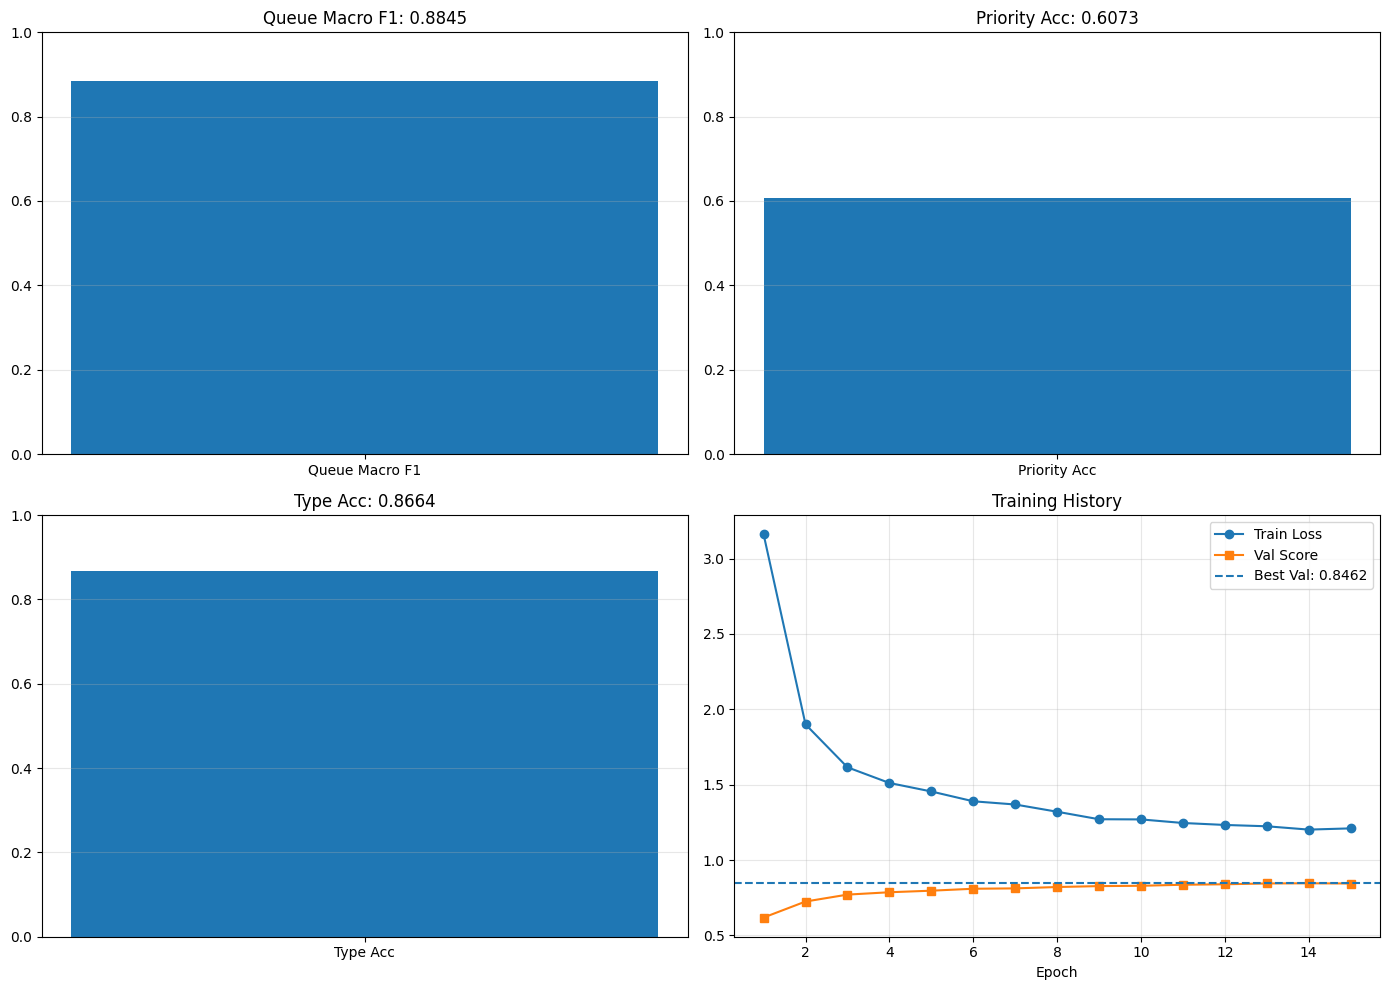


TRANSFORMER MULTITASK BETTER SUMMARY

Model: xlm-roberta-base
Device: cuda
Parameters: 279,863,102

Training: 3626.80s, Inference: 7.52s, Total: 3634.31s
Peak Memory: 2946.08MB

Results:
  Queue:     Acc=0.5699, Macro F1=0.8845
  Priority:  Acc=0.6073
  Type:      Acc=0.8664

FINAL SCORE: 0.8402

Best Validation Score: 0.8462


,model,base_model,epochs,batch_size,learning_rate_head,learning_rate_encoder,max_length,unfreeze_last_n_layers,layerwise_lr_decay,queue_acc,queue_macro_f1,priority_acc,type_acc,final_score,train_time_sec,infer_time_sec,total_time_sec,peak_memory_mb,num_params,best_val_score
0,Transformer_MultiTask_Better,xlm-roberta-base,15,16,0.0002,0.00002,384,4,0.9,0.569856,0.884542,0.607253,0.86644,0.840234,3626.795779,7.51728,3634.313059,2946.084473,279863102,0.846208


In [12]:
baseline_transformer_multitask(dfdicts)

# Это не основной трансформер (просто эксперимент) Sentence Embeddings using Supervised Contrastive Learning

Статья на которую опирался при проведении эксперимент: 
https://arxiv.org/abs/2106.04791

Хотел сначала из текста тикета строить sentence embeddings, затем эти эмбеддинги дополнительно дообучать так, чтобы тикеты одного класса были ближе друг к другу в векторном пространстве, а потом уже на этих эмбеддингах обучать обычные линейные классификаторы.

Сначала, как и в других блоках, текст собирается из:
subject + "\n\n" + body.

Далее в качестве базового encoder взял модель
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2.

Построил модель _ContrastiveTicketEncoder, которая состоит из:
  - sentence encoder
  -  dropout
  -  отдельная линейная голова queue_head

В отличие от multitask transformer baseline, здесь во время дообучения модель напрямую обучается только на задаче queue. В блоке sentence embeddings дополнительные задачи priority и type не участвуют в обучении encoder напрямую. Они используются только позже, когда на готовых эмбеддингах обучаются отдельные LinearSVC.

В обучении сочетаются две функции потерь:
  - Cross-Entropy loss по queue (чтобы модель продолжала хорошо различать конкретные классы основной задачи).
  - Supervised Contrastive Loss (чтобы объекты одного класса queue оказывались ближе друг к другу в embedding space, а объекты разных классов дальше).

Далее в _SupConLoss эмбеддинги сначала нормализуются, затем между всеми объектами батча считается матрица сходства.

объекты с одинаковым классом считаются positive pairs, с разными классами - negative pairs.

Модель штрафуется, если embeddings тикетов одного класса не сближаются, и если embeddings разных классов недостаточно разделены.

После contrastive fine-tuning модель кодирует train и test в векторные представления и уже поверх этих эмбеддингов для каждой задачи отдельно обучаются три LinearSVC.

Результат вышел хуже, чем у основного трансформера - на тесте метрика чуть меньше 0.8, далее не стал развивать эту идею т.к. для этого нужно лучше поработать с данными и их обработкой, больше времени и вычислительных мощностей.

In [ ]:
def _set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def _make_text(d: pd.DataFrame) -> pd.Series:
    return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)


def _compute_final_score(queue_macro_f1: float, priority_acc: float, type_acc: float) -> float:
    return 0.70 * queue_macro_f1 + 0.15 * priority_acc + 0.15 * type_acc


class _TicketDataset(Dataset):
    def __init__(self, texts: list[str], labels: np.ndarray):
        self.texts = texts
        self.labels = labels.astype(np.int64)

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int):
        return self.texts[idx], int(self.labels[idx])


def _collate_batch(batch):
    texts = [x[0] for x in batch]
    labels = torch.tensor([x[1] for x in batch], dtype=torch.long)
    return texts, labels


class _SupConLoss(nn.Module):
    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        device = embeddings.device
        z = F.normalize(embeddings, p=2, dim=1)
        sim = torch.matmul(z, z.T) / self.temperature
        logits_mask = torch.ones_like(sim, device=device) - torch.eye(sim.size(0), device=device)
        sim = sim - sim.max(dim=1, keepdim=True).values.detach()
        exp_sim = torch.exp(sim) * logits_mask

        labels = labels.contiguous().view(-1, 1)
        positive_mask = torch.eq(labels, labels.T).float().to(device)
        positive_mask = positive_mask * logits_mask

        log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)
        positive_count = positive_mask.sum(dim=1)
        mean_log_prob_pos = (positive_mask * log_prob).sum(dim=1) / positive_count.clamp_min(1.0)

        valid = positive_count > 0
        if valid.sum() == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)

        loss = -mean_log_prob_pos[valid].mean()
        return loss


class _ContrastiveTicketEncoder(nn.Module):
    def __init__(self, model_name: str, num_classes: int, dropout: float = 0.1):
        super().__init__()
        self.encoder = SentenceTransformer(model_name)
        emb_dim = self.encoder.get_sentence_embedding_dimension()
        self.dropout = nn.Dropout(dropout)
        self.queue_head = nn.Linear(emb_dim, num_classes)

    def forward(self, texts: list[str]):
        features = self.encoder.tokenize(texts)
        features = {k: v.to(self.device) for k, v in features.items()}
        out = self.encoder(features)
        emb = out["sentence_embedding"]
        logits = self.queue_head(self.dropout(emb))
        return emb, logits

    @property
    def device(self):
        return next(self.parameters()).device

    def encode(
        self,
        texts,
        batch_size: int = 128,
        convert_to_numpy: bool = True,
        normalize_embeddings: bool = True,
        show_progress_bar: bool = False,
    ):
        return self.encoder.encode(
            texts,
            batch_size=batch_size,
            convert_to_numpy=convert_to_numpy,
            normalize_embeddings=normalize_embeddings,
            show_progress_bar=show_progress_bar,
        )


@dataclass
class FastContrastiveConfig:
    model_name: str = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
    epochs: int = 7
    batch_size: int = 64
    lr: float = 2e-5
    weight_decay: float = 0.01
    max_grad_norm: float = 1.0
    temperature: float = 0.07
    ce_weight: float = 1.0
    supcon_weight: float = 1.0
    dropout: float = 0.1
    encoder_batch_size: int = 256
    eval_every: int = 1
    val_train_sample_size: int = 8000
    final_train_sample_size: int | None = None
    catboost_iterations: int = 300
    catboost_depth: int = 6
    catboost_learning_rate: float = 0.08
    seed: int = 42
    device: str | None = None


def _eval_contrastive_loss_on_loader(
    model: _ContrastiveTicketEncoder,
    loader: DataLoader,
    ce_loss_fn: nn.Module,
    supcon_loss_fn: nn.Module,
    ce_weight: float,
    supcon_weight: float,
) -> float:
    model.eval()
    losses = []
    device = model.device
    with torch.no_grad():
        for texts_batch, labels_batch in loader:
            labels_batch = labels_batch.to(device)
            emb, logits = model(texts_batch)
            loss_ce = ce_loss_fn(logits, labels_batch)
            loss_supcon = supcon_loss_fn(emb, labels_batch)
            loss = ce_weight * loss_ce + supcon_weight * loss_supcon
            losses.append(float(loss.detach().cpu().item()))
    return float(np.mean(losses)) if losses else np.nan


def _fit_linear_heads(
    train_emb: np.ndarray,
    eval_emb: np.ndarray,
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
) -> tuple[dict, dict]:
    results = {}
    models = {}
    preds = {}

    for target in ["queue", "priority", "type"]:
        ytr = train_df[target].astype(str).values
        yev = eval_df[target].astype(str).values

        clf = LinearSVC()
        clf.fit(train_emb, ytr)
        pred = clf.predict(eval_emb)

        models[target] = clf
        preds[target] = pred

        acc = float(accuracy_score(yev, pred))
        if target == "queue":
            mf1 = float(f1_score(yev, pred, average="macro"))
            results["queue_acc"] = acc
            results["queue_macro_f1"] = mf1
        else:
            results[f"{target}_acc"] = acc

    results["score"] = _compute_final_score(
        results["queue_macro_f1"],
        results["priority_acc"],
        results["type_acc"],
    )
    return results, {"models": models, "preds": preds}


def _fit_catboost_heads(
    train_emb: np.ndarray,
    eval_emb: np.ndarray,
    train_df: pd.DataFrame,
    eval_df: pd.DataFrame,
    iterations: int,
    depth: int,
    learning_rate: float,
    seed: int,
) -> tuple[dict, dict]:
    results = {}
    models = {}
    preds = {}

    for target in ["queue", "priority", "type"]:
        ytr = train_df[target].astype(str).values
        yev = eval_df[target].astype(str).values

        clf = CatBoostClassifier(
            loss_function="MultiClass",
            eval_metric="Accuracy",
            iterations=iterations,
            depth=depth,
            learning_rate=learning_rate,
            l2_leaf_reg=5.0,
            auto_class_weights="Balanced",
            random_seed=seed,
            verbose=False,
        )
        clf.fit(train_emb, ytr, verbose=False)
        pred = np.asarray(clf.predict(eval_emb)).reshape(-1).astype(str)

        models[target] = clf
        preds[target] = pred

        acc = float(accuracy_score(yev, pred))
        if target == "queue":
            mf1 = float(f1_score(yev, pred, average="macro"))
            results["queue_acc"] = acc
            results["queue_macro_f1"] = mf1
        else:
            results[f"{target}_acc"] = acc

    results["score"] = _compute_final_score(
        results["queue_macro_f1"],
        results["priority_acc"],
        results["type_acc"],
    )
    return results, {"models": models, "preds": preds}


def contrastive_sbert_linear_catboost_fast(
    splits: dict[str, pd.DataFrame],
    config: FastContrastiveConfig = FastContrastiveConfig(),
) -> tuple[_ContrastiveTicketEncoder, dict]:
    _set_seed(config.seed)

    train_df = splits["train"].reset_index(drop=True).copy()
    val_df = splits["val"].reset_index(drop=True).copy()
    test_df = splits["test"].reset_index(drop=True).copy()

    train_texts = _make_text(train_df).tolist()
    val_texts = _make_text(val_df).tolist()
    test_texts = _make_text(test_df).tolist()

    le_queue = LabelEncoder()
    y_train_queue = le_queue.fit_transform(train_df["queue"].astype(str).values)
    y_val_queue = le_queue.transform(val_df["queue"].astype(str).values)

    train_ds = _TicketDataset(train_texts, y_train_queue)
    val_ds = _TicketDataset(val_texts, y_val_queue)

    train_loader = DataLoader(
        train_ds,
        batch_size=config.batch_size,
        shuffle=True,
        drop_last=True,
        collate_fn=_collate_batch,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=config.batch_size,
        shuffle=False,
        drop_last=False,
        collate_fn=_collate_batch,
    )

    model = _ContrastiveTicketEncoder(
        model_name=config.model_name,
        num_classes=len(le_queue.classes_),
        dropout=config.dropout,
    )

    device = config.device or ("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config.lr,
        weight_decay=config.weight_decay,
    )

    ce_loss_fn = nn.CrossEntropyLoss()
    supcon_loss_fn = _SupConLoss(temperature=config.temperature)

    rng = np.random.default_rng(config.seed)

    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_score": [],
        "val_score": [],
        "train_queue_macro_f1": [],
        "val_queue_macro_f1": [],
        "train_priority_acc": [],
        "val_priority_acc": [],
        "train_type_acc": [],
        "val_type_acc": [],
    }

    best_val_score = -1.0
    best_state = None
    best_epoch = None

    val_train_sample_size = min(config.val_train_sample_size, len(train_df))
    train_sample_idx = rng.choice(len(train_df), size=val_train_sample_size, replace=False)
    train_df_small = train_df.iloc[train_sample_idx].reset_index(drop=True)
    train_texts_small = [train_texts[i] for i in train_sample_idx]

    for epoch in range(1, config.epochs + 1):
        model.train()
        epoch_losses = []

        for texts_batch, labels_batch in train_loader:
            labels_batch = labels_batch.to(device)

            optimizer.zero_grad()
            emb, logits = model(texts_batch)

            loss_ce = ce_loss_fn(logits, labels_batch)
            loss_supcon = supcon_loss_fn(emb, labels_batch)
            loss = config.ce_weight * loss_ce + config.supcon_weight * loss_supcon

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.max_grad_norm)
            optimizer.step()

            epoch_losses.append(float(loss.detach().cpu().item()))

        mean_train_loss = float(np.mean(epoch_losses))

        if epoch % config.eval_every == 0 or epoch == config.epochs:
            val_loss = _eval_contrastive_loss_on_loader(
                model=model,
                loader=val_loader,
                ce_loss_fn=ce_loss_fn,
                supcon_loss_fn=supcon_loss_fn,
                ce_weight=config.ce_weight,
                supcon_weight=config.supcon_weight,
            )

            train_emb_small = model.encode(
                train_texts_small,
                batch_size=config.encoder_batch_size,
                convert_to_numpy=True,
                normalize_embeddings=True,
                show_progress_bar=False,
            )
            val_emb = model.encode(
                val_texts,
                batch_size=config.encoder_batch_size,
                convert_to_numpy=True,
                normalize_embeddings=True,
                show_progress_bar=False,
            )

            train_metrics, _ = _fit_linear_heads(
                train_emb_small,
                train_emb_small,
                train_df_small,
                train_df_small,
            )
            val_metrics, _ = _fit_linear_heads(
                train_emb_small,
                val_emb,
                train_df_small,
                val_df,
            )

            history["epoch"].append(epoch)
            history["train_loss"].append(mean_train_loss)
            history["val_loss"].append(val_loss)
            history["train_score"].append(float(train_metrics["score"]))
            history["val_score"].append(float(val_metrics["score"]))
            history["train_queue_macro_f1"].append(float(train_metrics["queue_macro_f1"]))
            history["val_queue_macro_f1"].append(float(val_metrics["queue_macro_f1"]))
            history["train_priority_acc"].append(float(train_metrics["priority_acc"]))
            history["val_priority_acc"].append(float(val_metrics["priority_acc"]))
            history["train_type_acc"].append(float(train_metrics["type_acc"]))
            history["val_type_acc"].append(float(val_metrics["type_acc"]))

            print(
                f"epoch {epoch}/{config.epochs} - "
                f"train_loss={mean_train_loss:.4f} - "
                f"val_loss={val_loss:.4f} - "
                f"train_score={train_metrics['score']:.4f} - "
                f"val_score={val_metrics['score']:.4f}"
            )

            if val_metrics["score"] > best_val_score:
                best_val_score = float(val_metrics["score"])
                best_state = copy.deepcopy(model.state_dict())
                best_epoch = epoch
        else:
            print(f"epoch {epoch}/{config.epochs} - train_loss={mean_train_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    final_train_df = train_df
    final_train_texts = train_texts

    if config.final_train_sample_size is not None and config.final_train_sample_size < len(train_df):
        final_idx = rng.choice(len(train_df), size=config.final_train_sample_size, replace=False)
        final_train_df = train_df.iloc[final_idx].reset_index(drop=True)
        final_train_texts = [train_texts[i] for i in final_idx]

    train_emb = model.encode(
        final_train_texts,
        batch_size=config.encoder_batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    val_emb = model.encode(
        val_texts,
        batch_size=config.encoder_batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )
    test_emb = model.encode(
        test_texts,
        batch_size=config.encoder_batch_size,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    )

    linear_val_results, linear_val_artifacts = _fit_linear_heads(train_emb, val_emb, final_train_df, val_df)
    linear_test_results, linear_test_artifacts = _fit_linear_heads(train_emb, test_emb, final_train_df, test_df)

    cat_val_results, cat_val_artifacts = _fit_catboost_heads(
        train_emb=train_emb,
        eval_emb=val_emb,
        train_df=final_train_df,
        eval_df=val_df,
        iterations=config.catboost_iterations,
        depth=config.catboost_depth,
        learning_rate=config.catboost_learning_rate,
        seed=config.seed,
    )
    cat_test_results, cat_test_artifacts = _fit_catboost_heads(
        train_emb=train_emb,
        eval_emb=test_emb,
        train_df=final_train_df,
        eval_df=test_df,
        iterations=config.catboost_iterations,
        depth=config.catboost_depth,
        learning_rate=config.catboost_learning_rate,
        seed=config.seed,
    )

    head_summary_rows = [
        {
            "head_family": "LinearSVC",
            "val_score": linear_val_results["score"],
            "val_queue_macro_f1": linear_val_results["queue_macro_f1"],
            "val_priority_acc": linear_val_results["priority_acc"],
            "val_type_acc": linear_val_results["type_acc"],
            "test_score": linear_test_results["score"],
            "test_queue_macro_f1": linear_test_results["queue_macro_f1"],
            "test_priority_acc": linear_test_results["priority_acc"],
            "test_type_acc": linear_test_results["type_acc"],
        },
        {
            "head_family": "CatBoost",
            "val_score": cat_val_results["score"],
            "val_queue_macro_f1": cat_val_results["queue_macro_f1"],
            "val_priority_acc": cat_val_results["priority_acc"],
            "val_type_acc": cat_val_results["type_acc"],
            "test_score": cat_test_results["score"],
            "test_queue_macro_f1": cat_test_results["queue_macro_f1"],
            "test_priority_acc": cat_test_results["priority_acc"],
            "test_type_acc": cat_test_results["type_acc"],
        },
    ]
    head_summary = pd.DataFrame(head_summary_rows).sort_values(
        ["val_score", "val_queue_macro_f1"],
        ascending=[False, False],
    ).reset_index(drop=True)

    target_choice_rows = []
    final_val_preds = {}
    final_test_preds = {}
    final_head_models = {}

    for target in ["queue", "priority", "type"]:
        if target == "queue":
            linear_metric = linear_val_results["queue_macro_f1"]
            cat_metric = cat_val_results["queue_macro_f1"]
        else:
            linear_metric = linear_val_results[f"{target}_acc"]
            cat_metric = cat_val_results[f"{target}_acc"]

        if cat_metric > linear_metric:
            chosen_family = "CatBoost"
            chosen_val_pred = cat_val_artifacts["preds"][target]
            chosen_test_pred = cat_test_artifacts["preds"][target]
            chosen_model = cat_val_artifacts["models"][target]
            chosen_val_metric = cat_metric
        else:
            chosen_family = "LinearSVC"
            chosen_val_pred = linear_val_artifacts["preds"][target]
            chosen_test_pred = linear_test_artifacts["preds"][target]
            chosen_model = linear_val_artifacts["models"][target]
            chosen_val_metric = linear_metric

        final_val_preds[target] = chosen_val_pred
        final_test_preds[target] = chosen_test_pred
        final_head_models[target] = chosen_model

        target_choice_rows.append(
            {
                "target": target,
                "chosen_head_family": chosen_family,
                "val_metric_used_for_selection": chosen_val_metric,
            }
        )

    hybrid_val_queue_acc = float(accuracy_score(val_df["queue"].astype(str).values, final_val_preds["queue"]))
    hybrid_val_queue_macro_f1 = float(f1_score(val_df["queue"].astype(str).values, final_val_preds["queue"], average="macro"))
    hybrid_val_priority_acc = float(accuracy_score(val_df["priority"].astype(str).values, final_val_preds["priority"]))
    hybrid_val_type_acc = float(accuracy_score(val_df["type"].astype(str).values, final_val_preds["type"]))
    hybrid_val_score = _compute_final_score(
        hybrid_val_queue_macro_f1,
        hybrid_val_priority_acc,
        hybrid_val_type_acc,
    )

    hybrid_test_queue_acc = float(accuracy_score(test_df["queue"].astype(str).values, final_test_preds["queue"]))
    hybrid_test_queue_macro_f1 = float(f1_score(test_df["queue"].astype(str).values, final_test_preds["queue"], average="macro"))
    hybrid_test_priority_acc = float(accuracy_score(test_df["priority"].astype(str).values, final_test_preds["priority"]))
    hybrid_test_type_acc = float(accuracy_score(test_df["type"].astype(str).values, final_test_preds["type"]))
    hybrid_test_score = _compute_final_score(
        hybrid_test_queue_macro_f1,
        hybrid_test_priority_acc,
        hybrid_test_type_acc,
    )

    target_choice = pd.DataFrame(target_choice_rows)

    results = {
        "best_epoch": best_epoch,
        "best_val_score_during_training": best_val_score,
        "linear_val_results": linear_val_results,
        "linear_test_results": linear_test_results,
        "catboost_val_results": cat_val_results,
        "catboost_test_results": cat_test_results,
        "hybrid_val_results": {
            "queue_acc": hybrid_val_queue_acc,
            "queue_macro_f1": hybrid_val_queue_macro_f1,
            "priority_acc": hybrid_val_priority_acc,
            "type_acc": hybrid_val_type_acc,
            "score": hybrid_val_score,
        },
        "hybrid_test_results": {
            "queue_acc": hybrid_test_queue_acc,
            "queue_macro_f1": hybrid_test_queue_macro_f1,
            "priority_acc": hybrid_test_priority_acc,
            "type_acc": hybrid_test_type_acc,
            "score": hybrid_test_score,
        },
        "head_summary": head_summary,
        "target_choice": target_choice,
        "history": history,
        "train_embeddings": train_emb,
        "val_embeddings": val_emb,
        "test_embeddings": test_emb,
        "final_head_models": final_head_models,
    }

    print("\n=== CONTRASTIVE SBERT + TWO HEAD FAMILIES ===")
    print(f"best_epoch: {results['best_epoch']}")

    print("\n--- LinearSVC heads ---")
    print(
        f"VAL  -> score={linear_val_results['score']:.4f}  "
        f"queue_f1={linear_val_results['queue_macro_f1']:.4f}  "
        f"priority_acc={linear_val_results['priority_acc']:.4f}  "
        f"type_acc={linear_val_results['type_acc']:.4f}"
    )
    print(
        f"TEST -> score={linear_test_results['score']:.4f}  "
        f"queue_f1={linear_test_results['queue_macro_f1']:.4f}  "
        f"priority_acc={linear_test_results['priority_acc']:.4f}  "
        f"type_acc={linear_test_results['type_acc']:.4f}"
    )

    print("\n--- CatBoost heads ---")
    print(
        f"VAL  -> score={cat_val_results['score']:.4f}  "
        f"queue_f1={cat_val_results['queue_macro_f1']:.4f}  "
        f"priority_acc={cat_val_results['priority_acc']:.4f}  "
        f"type_acc={cat_val_results['type_acc']:.4f}"
    )
    print(
        f"TEST -> score={cat_test_results['score']:.4f}  "
        f"queue_f1={cat_test_results['queue_macro_f1']:.4f}  "
        f"priority_acc={cat_test_results['priority_acc']:.4f}  "
        f"type_acc={cat_test_results['type_acc']:.4f}"
    )

    print("\n--- Best per target hybrid ---")
    print(target_choice.to_string(index=False))
    print(
        f"VAL  -> score={hybrid_val_score:.4f}  "
        f"queue_f1={hybrid_val_queue_macro_f1:.4f}  "
        f"priority_acc={hybrid_val_priority_acc:.4f}  "
        f"type_acc={hybrid_val_type_acc:.4f}"
    )
    print(
        f"TEST -> score={hybrid_test_score:.4f}  "
        f"queue_f1={hybrid_test_queue_macro_f1:.4f}  "
        f"priority_acc={hybrid_test_priority_acc:.4f}  "
        f"type_acc={hybrid_test_type_acc:.4f}"
    )

    _plot_fast_contrastive_history(history)
    _plot_head_family_performance(head_summary, target_choice)

    return model, results


def _plot_fast_contrastive_history(history: dict) -> None:
    epochs = history["epoch"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(epochs, history["train_loss"], marker="o", linewidth=2, label="Train loss")
    axes[0].plot(epochs, history["val_loss"], marker="s", linewidth=2, label="Val loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Train / Val loss by epoch")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, history["train_score"], marker="o", linewidth=2, label="Train score")
    axes[1].plot(epochs, history["val_score"], marker="s", linewidth=2, label="Val score")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_title("Train / Val score by epoch")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    axes[0].plot(epochs, history["train_queue_macro_f1"], marker="o", linewidth=2, label="Train queue F1")
    axes[0].plot(epochs, history["val_queue_macro_f1"], marker="s", linewidth=2, label="Val queue F1")
    axes[0].set_title("Queue Macro-F1")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Macro-F1")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, history["train_priority_acc"], marker="o", linewidth=2, label="Train priority acc")
    axes[1].plot(epochs, history["val_priority_acc"], marker="s", linewidth=2, label="Val priority acc")
    axes[1].set_title("Priority Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[2].plot(epochs, history["train_type_acc"], marker="o", linewidth=2, label="Train type acc")
    axes[2].plot(epochs, history["val_type_acc"], marker="s", linewidth=2, label="Val type acc")
    axes[2].set_title("Type Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Accuracy")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def _plot_head_family_performance(head_summary: pd.DataFrame, target_choice: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

    x = np.arange(len(head_summary))
    width = 0.35

    axes[0].bar(x - width / 2, head_summary["val_score"], width, label="Val")
    axes[0].bar(x + width / 2, head_summary["test_score"], width, label="Test")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(head_summary["head_family"])
    axes[0].set_title("Final score by head family")
    axes[0].set_ylabel("Score")
    axes[0].grid(True, axis="y", alpha=0.3)
    axes[0].legend()

    metric_names = ["queue_macro_f1", "priority_acc", "type_acc"]
    display_names = ["Queue F1", "Priority Acc", "Type Acc"]
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for i, (metric, display, color) in enumerate(zip(metric_names, display_names, colors)):
        vals = head_summary[f"val_{metric}"].values
        axes[1].bar(
            x + (i - 1) * 0.22,
            vals,
            width=0.22,
            label=display,
            color=color,
        )
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(head_summary["head_family"])
    axes[1].set_title("Validation metrics by head family")
    axes[1].set_ylabel("Metric")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].legend()

    family_counts = target_choice["chosen_head_family"].value_counts()
    families = ["LinearSVC", "CatBoost"]
    counts = [int(family_counts.get(f, 0)) for f in families]
    axes[2].bar(families, counts)
    axes[2].set_title("Chosen family per target")
    axes[2].set_ylabel("Number of targets")
    axes[2].grid(True, axis="y", alpha=0.3)

    for idx, row in target_choice.iterrows():
        axes[2].text(
            idx if idx < len(families) else 0,
            0,
            "",
        )

    plt.tight_layout()
    plt.show()

epoch 1/15 - train_loss=6.1570 - val_loss=5.6792 - train_score=0.7222 - val_score=0.6699
epoch 2/15 - train_loss=5.3698 - val_loss=5.1176 - train_score=0.7636 - val_score=0.7104
epoch 3/15 - train_loss=5.0300 - val_loss=4.8787 - train_score=0.7801 - val_score=0.7348
epoch 4/15 - train_loss=4.8082 - val_loss=4.7717 - train_score=0.7930 - val_score=0.7497
epoch 5/15 - train_loss=4.6219 - val_loss=4.6504 - train_score=0.8060 - val_score=0.7563
epoch 6/15 - train_loss=4.4474 - val_loss=4.6233 - train_score=0.8132 - val_score=0.7641
epoch 7/15 - train_loss=4.2687 - val_loss=4.6429 - train_score=0.8223 - val_score=0.7685
epoch 8/15 - train_loss=4.1057 - val_loss=4.6179 - train_score=0.8279 - val_score=0.7711
epoch 9/15 - train_loss=3.9254 - val_loss=4.6590 - train_score=0.8348 - val_score=0.7768
epoch 10/15 - train_loss=3.7641 - val_loss=4.7477 - train_score=0.8424 - val_score=0.7758
epoch 11/15 - train_loss=3.5989 - val_loss=4.8313 - train_score=0.8464 - val_score=0.7803
epoch 12/15 - train

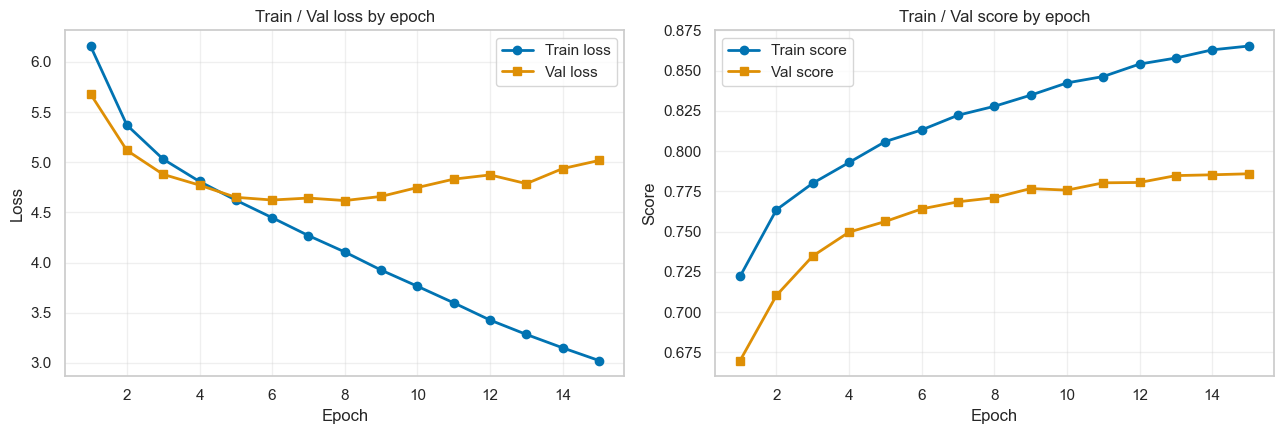

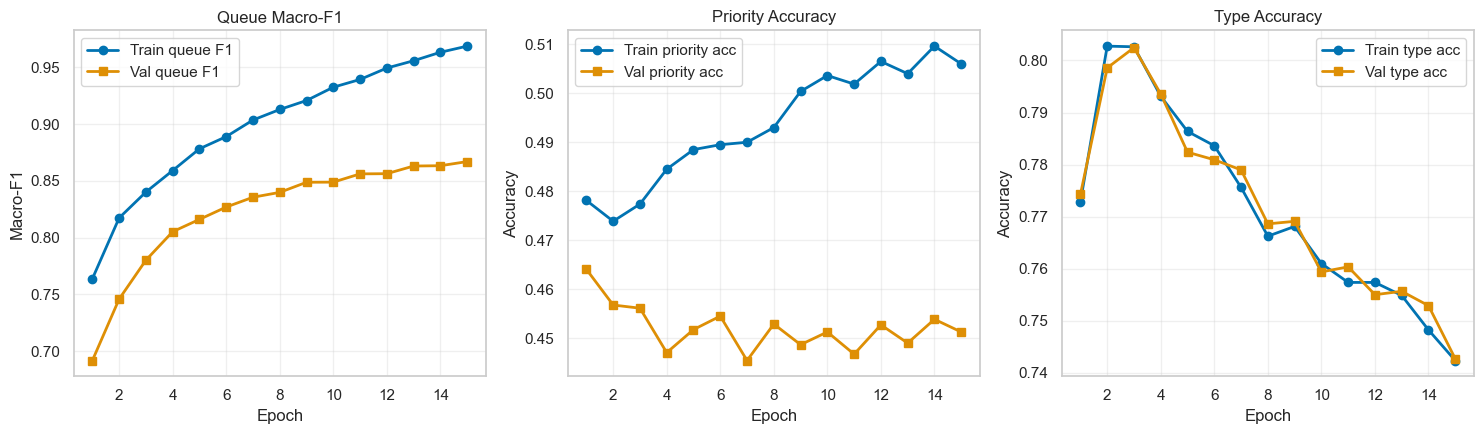

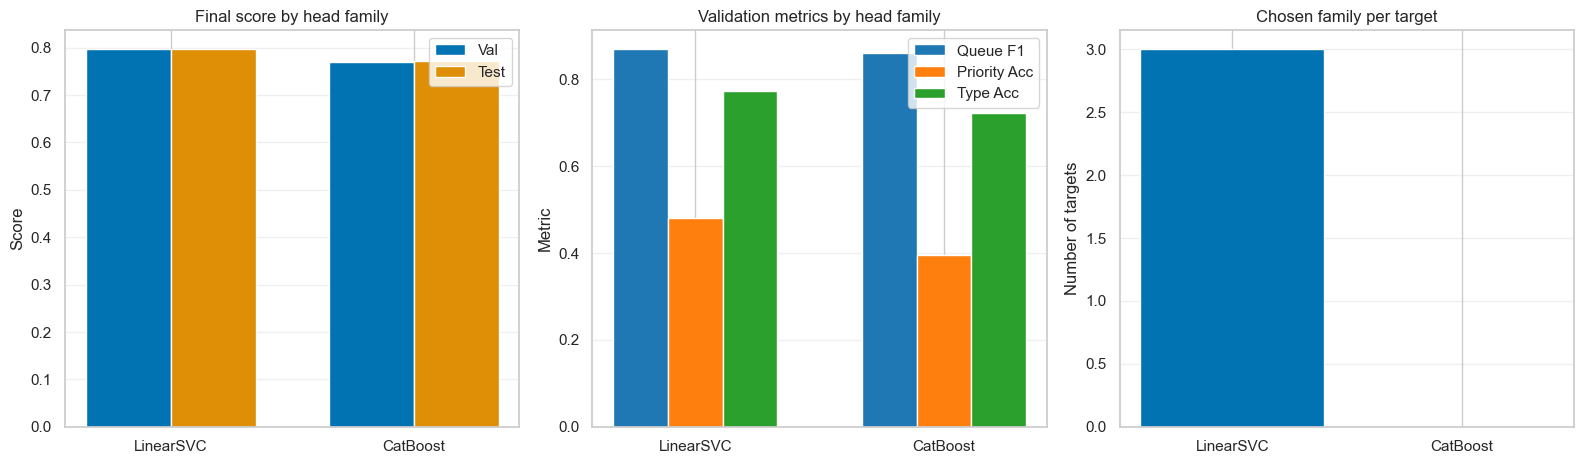

In [5]:
config = FastContrastiveConfig(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    epochs=15,
    batch_size=64,
    lr=2e-5,
    encoder_batch_size=256,
    eval_every=1,
    val_train_sample_size=8000,
    final_train_sample_size=None,
    catboost_iterations=300,
    catboost_depth=6,
    catboost_learning_rate=0.08,
    seed=42,
)

model, results = contrastive_sbert_linear_catboost_fast(dfdicts, config)

In [7]:
results["head_summary"]

,head_family,val_score,val_queue_macro_f1,val_priority_acc,val_type_acc,test_score,test_queue_macro_f1,test_priority_acc,test_type_acc
0,LinearSVC,0.796666,0.869508,0.480408,0.772992,0.796264,0.870852,0.470455,0.774000
1,CatBoost,0.770060,0.860299,0.395240,0.723769,0.771459,0.865734,0.389348,0.713615


In [8]:
results["target_choice"]

,target,chosen_head_family,val_metric_used_for_selection
0,queue,LinearSVC,0.869508
1,priority,LinearSVC,0.480408
2,type,LinearSVC,0.772992


In [9]:
results["hybrid_val_results"]

{'queue_acc': 0.6428108808290155,
 'queue_macro_f1': 0.8695079628785106,
 'priority_acc': 0.4804080310880829,
 'type_acc': 0.7729922279792746,
 'score': 0.796665612875061}

In [10]:
results["hybrid_test_results"]

{'queue_acc': 0.6363930710700988,
 'queue_macro_f1': 0.8708516974250272,
 'priority_acc': 0.47045491338837625,
 'type_acc': 0.7740003237817711,
 'score': 0.7962644737730411}